# Анализ отмен

**Цель:** анализ отмен бронирований (ответ на 6 бизнес-вопросов), оценка выручки под риском и практические рекомендации.

**Вход:** `data/processed/hotels_clean.csv` (результат ноутбука 01).

**Ключевое правило раздела:** сравнение долей отмен по группам, а не линейные корреляции - в датасете почти нет сильных линейных связей.

In [1]:
# Standard library
from pathlib import Path

# Data
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu

# Viz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Viz for output
from IPython.display import display, HTML

# Pandas display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Стиль графиков

Задаём единый стиль, один для всех графиков.<br>

In [2]:
# Seabern display settings
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette='deep',
    rc={
        'figure.figsize': (9, 5),
        'axes.titlesize': 13,
        'axes.titleweight': 'bold',
        'axes.labelsize': 11,
        'axes.spines.top': False,
        'axes.spines.right': False,
    },
)

## Загрузка данных

Ноутбук лежит в `notebooks/`, датасет - в `data/processed/`.<br>
Используем относительный путь - так ноутбук воспроизводим после `git clone`.

In [3]:
# Read data
DATA_PATH = Path('../data/processed/hotels_clean.csv')
assert DATA_PATH.exists(), f'File not found: {DATA_PATH.resolve()}'

df = pd.read_csv(DATA_PATH)
display(HTML(f'<b>Загружено:</b> {df.shape[0]:,} rows x {df.shape[1]} columns'))

## Проверка корректности данных

Сверяем размер и общую долю отмен. Ожидаем 119 385 строк и 37% отмен.<br>
Если цифры не совпали, нужно выяснить причину перед дальнейшим анализом.

In [4]:
n_rows = len(df)
cancel_rate_overall = df['is_canceled'].mean()

print(f'Rows:                  {n_rows:,}')
print(f'Cancellation rate:     {cancel_rate_overall:.2%}')
print(f'is_canceled values:    {sorted(df["is_canceled"].unique().tolist())}')

Rows:                  119,385
Cancellation rate:     37.04%
is_canceled values:    [0, 1]


## Приведение типов и защита от дублирования информации

**Категориальные колонки** переводим в `category`

**Дублирование информации.** 
Колонки `reservation_status` и `reservation_status_date` описывают **финал** брони, а не её характеристики на момент бронирования. Использовать их как "факторы отмены" нельзя - получим ~100% связи. Оставляем в датасете, но исключаем из анализа.

In [5]:
CATEGORICAL_COLS = [
    'hotel', 'meal', 'market_segment',
    'distribution_channel', 'customer_type', 'deposit_type',
    'reservation_status', 'reserved_room_type', 'assigned_room_type',
    'country',
]

# Columns that must NOT be used as predictors (target leakage).
LEAKAGE_COLS = ['reservation_status', 'reservation_status_date']

# Filter to existing columns only (in case some were dropped in nb 01).
existing_cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
df[existing_cat_cols] = df[existing_cat_cols].astype('category')

MONTHS_ORDER = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December',
]

if 'arrival_date_month' in df.columns:
    df['arrival_date_month'] = pd.Categorical(
        df['arrival_date_month'],
        categories=MONTHS_ORDER,
        ordered=True,
    )

print('Dtypes:')
print(df[existing_cat_cols].dtypes)

Dtypes:
hotel                   category
meal                    category
market_segment          category
distribution_channel    category
customer_type           category
deposit_type            category
reservation_status      category
reserved_room_type      category
assigned_room_type      category
country                 category
dtype: object


## Вспомогательные функции

Три функции, которые будут использоваться почти в каждой секции. Чтобы не дублировать код и сделать единообразное отображение введём вспомогательные функции.

| Функция | Что делает |
|---|---|
| `cancel_rate(df, by)` | Таблица: группа -> n_bookings, n_canceled, cancel_rate |
| `cancel_rate_table(df, by, min_n)` | То же + фильтр по минимальному размеру группы |
| `plot_cancel_rate(df, by, ...)` | Горизонтальный бар-чарт долей отмен |
| `cancel_heatmap(df, by, ...)` | Heatmap долей отмен |

In [6]:
def cancel_rate(df: pd.DataFrame, by: str | list[str]) -> pd.DataFrame:
    """
    Compute cancellation rate per group.

    Parameters
    ----------
    df : pd.DataFrame
    by : str or list of str | Column name(s) to group by.

    Returns
    -------
    pd.DataFrame with columns [*by, 'n_bookings', 'n_canceled', 'cancel_rate'], sorted by cancel_rate descending.
    """
    by_list = [by] if isinstance(by, str) else list(by)

    grouped = (
        df.groupby(by_list, observed=True)
          .agg(
              n_bookings=('is_canceled', 'size'),
              n_canceled=('is_canceled', 'sum'),
          )
          .reset_index()
    )
    grouped['cancel_rate'] = grouped['n_canceled'] / grouped['n_bookings']
    return grouped.sort_values('cancel_rate', ascending=False).reset_index(drop=True)


def cancel_rate_table(df: pd.DataFrame, by: str | list[str], min_n: int = 100) -> pd.DataFrame:
    """
    Same as cancel_rate, but drop groups smaller than min_n (avoids 100% on n=3).
    """
    table = cancel_rate(df, by)
    return table[table['n_bookings'] >= min_n].reset_index(drop=True)


def plot_cancel_rate(
    df: pd.DataFrame,
    by: str,
    min_n: int = 100,
    top_n: int | None = None,
    title: str | None = None,
    ax=None
):
    """
    Horizontal bar chart of cancellation rate by a single column.

    top_n : int or None | if set, keep only top_n groups with the highest cancellation rate.
    """
    table = cancel_rate_table(df, by, min_n=min_n)
    if top_n is not None:
        table = table.nlargest(top_n, 'cancel_rate')

    table = table.sort_values('cancel_rate') 

    if ax is None:
        _, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(table))))

    ax.barh(
        table[by].astype(str),
        table['cancel_rate'],
        color='steelblue',
    )
    ax.axvline(
        df['is_canceled'].mean(),
        color='firebrick',
        linestyle='--',
        linewidth=1,
        label=f'Overall = {df["is_canceled"].mean():.1%}',
    )
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel('Cancellation rate')
    ax.set_ylabel(by)
    ax.set_title(title or f'Cancellation rate by {by}')
    ax.legend(loc='lower right')

    for i, (_, row) in enumerate(table.iterrows()):
        ax.text(
            row['cancel_rate'] + 0.005, i,
            f'n={row["n_bookings"]:,}',
            va='center', fontsize=9, color='dimgray',
        )

    return ax, table

def cancel_heatmap(df, index, columns, min_n=100, title=None, ax=None):
    """
    Heatmap chart of cancellation rate by a single column.
    """
    rate = df.pivot_table(
        index=index, columns=columns,
        values='is_canceled', aggfunc='mean',
        observed=True,
    )
    n = df.pivot_table(
        index=index, columns=columns,
        values='is_canceled', aggfunc='size',
        observed=True,
    )
    rate_masked = rate.mask(n < min_n)

    if ax is None:
        _, ax = plt.subplots(figsize=(1.4 * len(rate.columns) + 3, 0.5 * len(rate.index) + 2))

    sns.heatmap(
        rate_masked, ax=ax,
        cmap='RdYlGn_r', vmin=0, vmax=0.8,
        annot=True, fmt='.0%',
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Cancellation rate',
                  'format': mticker.PercentFormatter(1.0)},
    )
    ax.set_title(title or f'Cancellation rate: {index} × {columns}')
    ax.set_xlabel(columns)
    ax.set_ylabel(index)
    return ax

In [7]:
# Quick smoke test
print(f'Overall cancellation rate: {df["is_canceled"].mean():.2%}')
print()

cancel_rate_table(df, 'hotel')[['hotel', 'n_bookings', 'n_canceled', 'cancel_rate']]

Overall cancellation rate: 37.04%



,hotel,n_bookings,n_canceled,cancel_rate
0,City Hotel,79327,33101,0.42
1,Resort Hotel,40058,11121,0.28


## Известный феномен: "пакетные" отмены

В датасете (особенно в City Hotel, сегменте Groups, канале TA/TO) встречаются блоки похожих записей, почти все помеченные `is_canceled = 1`. Возможные причины: bulk-загрузки из PMS, массовые отмены групп, технические дубликаты.

# BQ1. Насколько велика проблема отмен?

Разбиваем на три слоя:
1. Общий масштаб - одна цифра.
2. Разрез по отелям - в предыдущем nb было видно, что в City отмен больше.
3. Динамика во времени - стабильна ли проблема.

**Важно:** 2015 и 2017 неполные (Jul-Dec и Jan-Aug соответственно).
Не сравниваем их напрямую с полным 2016. Показываем помесячно с явной пометкой диапазонов.

In [8]:
n_total = len(df)
n_canceled = int(df['is_canceled'].sum())
n_not_canceled = n_total - n_canceled
rate_overall = df['is_canceled'].mean()

print(f'Всего броней:        {n_total:>8,}')
print(f'Отменено:           {n_canceled:>8,}  ({rate_overall:.2%})')
print(f'Не отменено:        {n_not_canceled:>8,}  ({1 - rate_overall:.2%})')

Всего броней:         119,385
Отменено:             44,222  (37.04%)
Не отменено:          75,163  (62.96%)


## 1.2. Разрез по отелям

City и Resort - разные бизнес-модели:<br>
- City ориентирован на короткие деловые поездки и TA/TO-каналы<br>
- Resort - на сезонные туристические брони.<br>

Проверяем, подтверждается ли это различием в доле отмен.

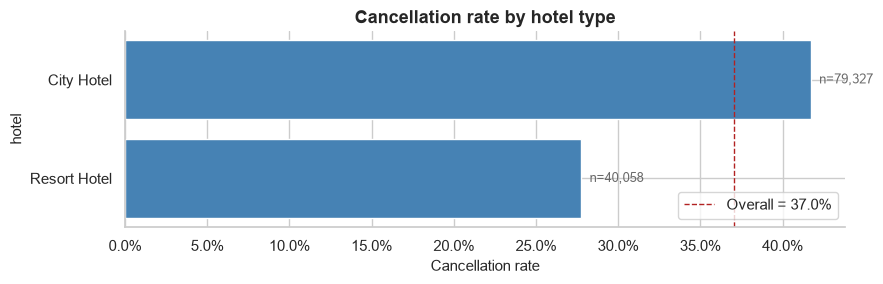

hotel,n_bookings,n_canceled,cancel_rate
Resort Hotel,40058,11121,0.28
City Hotel,79327,33101,0.42


In [9]:
ax, table = plot_cancel_rate(
    df, by='hotel',
    min_n=0,
    title='Cancellation rate by hotel type',
)
plt.tight_layout()
plt.show()

html = table.to_html(index=False).replace(
    '<table', '<table style="display:inline-block;"'
)
display(HTML(f"<br><div style='text-align:center;'>{html}</div>"))

## 1.3. Динамика во времени

Считаем долю отмен по (год x месяц). Смотрим:
- **График A (линии по годам)** - есть ли устойчивая сезонность, повторяется ли рисунок из года в год.
- **График B (heatmap)** - детальный вид "месяц x год": сразу видно периоды и различия между годами.

In [10]:
dyn = cancel_rate_table(df, ['arrival_date_year', 'arrival_date_month'])
dyn.head()

,arrival_date_year,arrival_date_month,n_bookings,n_canceled,cancel_rate
0,2015,July,2775,1258,0.45
1,2017,May,6313,2762,0.44
2,2017,April,5661,2463,0.44
3,2017,June,5647,2439,0.43
4,2015,August,3889,1598,0.41


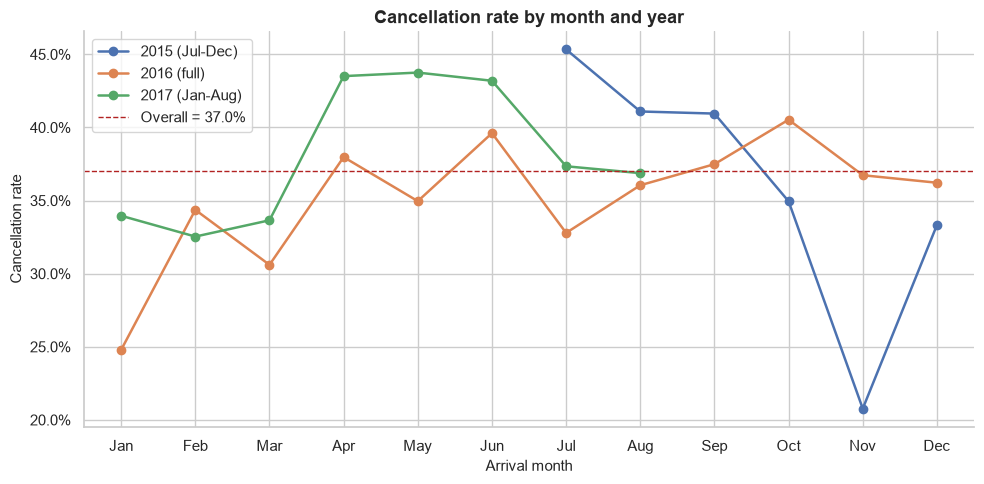

In [11]:
MONTHS_SHORT = [m[:3] for m in MONTHS_ORDER]

dyn['month_num'] = dyn['arrival_date_month'].cat.codes

year_labels = {}
for year, sub in dyn.groupby('arrival_date_year', observed=True):
    months = (sub['arrival_date_month']
              .dropna()
              .drop_duplicates()
              .sort_values()                  
              .astype(str)
              .tolist())
    if len(months) == 12:
        span = 'full'
    else:
        span = f'{months[0][:3]}-{months[-1][:3]}'  
    year_labels[year] = f'{year} ({span})'


fig, ax = plt.subplots(figsize=(10, 5))

for year, sub in dyn.groupby('arrival_date_year', observed=True):
    sub = sub.sort_values('month_num')             
    ax.plot(
        sub['month_num'],                        
        sub['cancel_rate'],
        marker='o',
        linewidth=1.8,
        label=year_labels[year],
    )


overall = df['is_canceled'].mean()
ax.axhline(
    overall,
    color='firebrick',
    linestyle='--',
    linewidth=1,
    label=f'Overall = {overall:.1%}',
)

ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS_SHORT)
ax.set_xlim(-0.5, 11.5)   

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Arrival month')
ax.set_ylabel('Cancellation rate')
ax.set_title('Cancellation rate by month and year')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

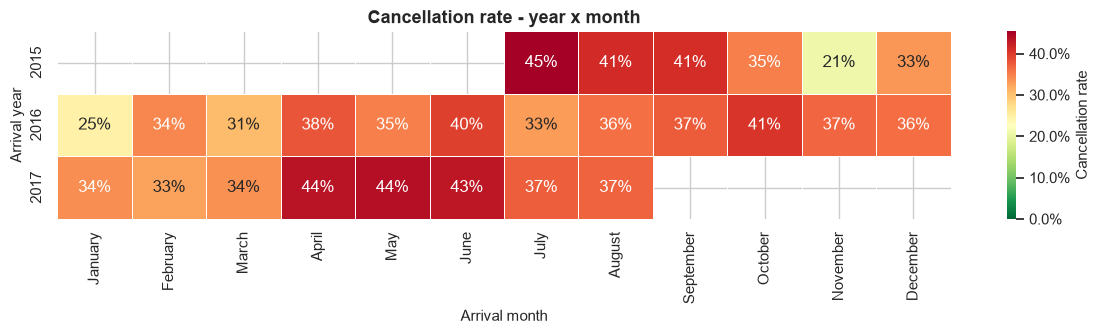

In [12]:
heat = (
    dyn.pivot(index='arrival_date_year',
              columns='arrival_date_month',
              values='cancel_rate')
)

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    heat,
    annot=True, fmt='.0%',
    cmap='RdYlGn_r',
    vmin=0, vmax=heat.max().max(),
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Cancellation rate', 'format': mticker.PercentFormatter(1.0)},
    ax=ax,
)
ax.set_xlabel('Arrival month')
ax.set_ylabel('Arrival year')
ax.set_title('Cancellation rate - year x month')
plt.tight_layout()
plt.show()

## 1.4. Вывод по BQ1

- **Масштаб.** 37% - системная характеристика, а не "шум".
  44 222 отменённых броней из 119 385.
- **Два разных отеля.** City (42%) отменяется в 1.5 раза чаще Resort (28%).
- **Сезонность - есть, но нестабильная.** Рисунок отмен меняется год к году:<br>
    - 2016 даёт два пика (Apr-Jun, Oct)
    - 2017 - один (Apr-Jun)
    - 2015 обваливается в ноябре (21%) вопреки тренду.
Значит, корень проблемы не в сезонности как таковой.
- **2017 Q2 выше 2016 Q2** (44% и 38%) - возможный тренд роста отмен, требует отдельной проверки.
- **Ограничение.** 2015 и 2017 неполные - прямые годовые сравнения некорректны, но помесячные паттерны внутри каждого года видеть можно.
- **Заметки к BQ2:** раз сезонность "рваная", что значит - дело в структурных факторах. Проверим `lead_time`, день недели и повторные брони - то, что управляется политикой отеля.

# BQ2. Когда отменяют чаще?

Три среза:
- **2.1 `lead_time`** - за сколько дней до заезда бронируют "отменяемые" гости
- **2.2 День недели приезда** - есть ли "плохие" дни
- **2.3 `lead_time` x месяц** - управляемо ли отменяемое поведение по сезону

Сезонность по месяцам уже разобрана в BQ1.

## 2.1. `lead_time`

`lead_time` - число дней между бронированием и заездом.<br>
Гипотеза: чем раньше бронь, тем выше шанс, что планы поменяются.<br>

Смотрим два угла:
1. **Распределение** - отличается ли `lead_time` у отменённых и неотменённых броней
2. **Доля отмены по корзинам** - в каком сегменте lead_time больше всего отмен

In [13]:
LEAD_BINS   = [0, 1, 7, 14, 30, 60, 90, 180, 365, np.inf]
LEAD_LABELS = ['0', '1-7', '8-14', '15-30', '31-60',
               '61-90', '91-180', '181-365', '365+']

df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=LEAD_BINS,
    labels=LEAD_LABELS,
    right=True,
    include_lowest=True,
).cat.as_ordered()

lead_stats = (
    df.groupby('is_canceled')['lead_time']
      .describe()[['count', 'mean', '50%', '75%', 'max']]
      .rename(columns={'50%': 'median', '75%': 'q75'})
      .round(1)
)
lead_stats.index = lead_stats.index.map({0: 'not canceled', 1: 'canceled'})
lead_stats

,count,mean,median,q75,max
is_canceled,,,,,
not canceled,"75,163.00",80.00,45.00,124.00,737.00
canceled,"44,222.00",144.90,113.00,214.00,629.00


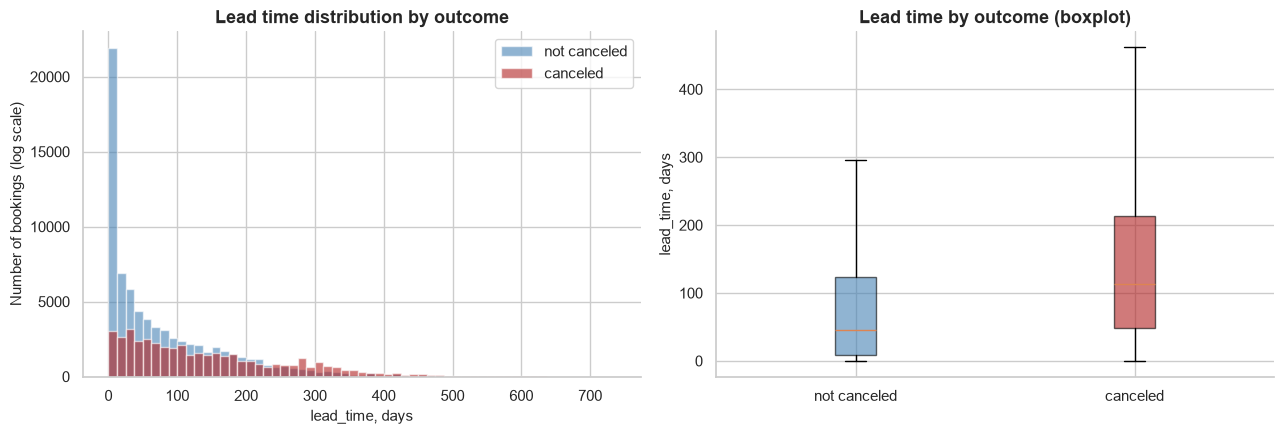

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, df['lead_time'].max(), 60)
axes[0].hist(
    df.loc[df['is_canceled'] == 0, 'lead_time'],
    bins=bins, alpha=0.6, label='not canceled', color='steelblue',
)
axes[0].hist(
    df.loc[df['is_canceled'] == 1, 'lead_time'],
    bins=bins, alpha=0.6, label='canceled', color='firebrick',
)          
axes[0].set_xlabel('lead_time, days')
axes[0].set_ylabel('Number of bookings (log scale)')
axes[0].set_title('Lead time distribution by outcome')
axes[0].legend()

box_data = [
    df.loc[df['is_canceled'] == 0, 'lead_time'],
    df.loc[df['is_canceled'] == 1, 'lead_time'],
]
bp = axes[1].boxplot(
    box_data,
    tick_labels=['not canceled', 'canceled'],
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(bp['boxes'], ['steelblue', 'firebrick']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('lead_time, days')
axes[1].set_title('Lead time by outcome (boxplot)')

plt.tight_layout()
plt.show()

## 2.1. Вывод

- **Медиана `lead_time`**: 45 дней у неотменённых и 113 дней у отменённых - в 2.5 раза больше. Сдвиг происходит на всём распределении, а не только в "хвосте" (Q75: 124 и 214).
- **Практический смысл:** типичная отменяемая бронь - "дальняя". Первые ~2 недели до заезда - "безопасны" в плане отмен.
- **Что это меняет:** напоминания и депозитная политика становятся осмысленными именно для длинных lead_time.

## 2.2. День недели приезда

Собираем `arrival_date` из year / month / day_of_month, и получаем день недели.

**Зачем:** Если "плохие" дни - это выходные, значит, причина в типе поездки. Если это понедельник - скорее business-брони. Можно получить разные сегменты и дать соответствующие рекомендации.

In [15]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d',
    errors='coerce',
)

n_bad = df['arrival_date'].isna().sum()
if n_bad > 0:
    print(f'Unparsed dates: {n_bad:,} of {len(df):,}')

df['arrival_dow'] = df['arrival_date'].dt.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['arrival_dow'] = pd.Categorical(df['arrival_dow'], categories=dow_order, ordered=True)

df[['arrival_date', 'arrival_dow']].head(3)

,arrival_date,arrival_dow
0,2015-07-01,Wednesday
1,2015-07-01,Wednesday
2,2015-07-01,Wednesday


In [16]:
dow_table = cancel_rate_table(df, 'arrival_dow')
dow_table

,arrival_dow,n_bookings,n_canceled,cancel_rate
0,Thursday,19254,7927,0.41
1,Friday,19630,7977,0.41
2,Saturday,18055,7129,0.39
3,Wednesday,16139,5831,0.36
4,Monday,18171,6195,0.34
5,Tuesday,13998,4600,0.33
6,Sunday,14138,4563,0.32


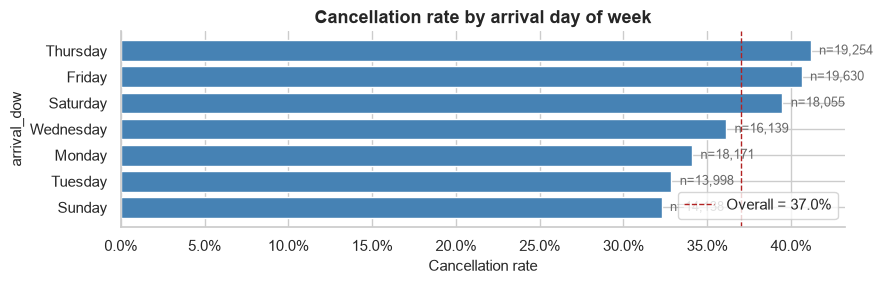

In [17]:
ax, _ = plot_cancel_rate(
    df, by='arrival_dow',
    min_n=0,
    title='Cancellation rate by arrival day of week',
)
plt.tight_layout()
plt.show()

## 2.2. Вывод

- **Разброс по дням недели - 9%:** Thursday/Friday (41%) и Sunday (32%). Все группы n > 13 000.
- **Weekend-эффекта нет.** Суббота в середине (39%), воскресенье - в самом низу (32%). Значит, причина не в выходных.
- **Гипотеза о бизнес-паттерне:** заезды в четверг/пятницу - это либо длинные weekend-поездки, либо командировки с заездом заранее; такие брони оформляются с большим `lead_time` -> выше риск.
- **Практический смысл:** день недели приезда - слабый, но ненулевой. В связке с `lead_time` может стать управляемым рычагом.

Следующий шаг - `lead_time` x месяц. Проверим, "сгущается" ли риск в конкретных месячно-горизонтных зонах.

## 2.3. `lead_time` x месяц (heatmap по годам)

Смотрим, в каком сегменте большой риск: пересечение длинного горизонта брони и сезона приезда.

- **Строки:** корзины `lead_time_bin` (из 2.1).
- **Столбцы:** месяц приезда.
- **Цвет:** доля отмены.
- **Белые клетки:** слишком мало данных (n < 30) - не интерпретируем.

In [18]:
MONTHS_ORDER = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

MIN_N_CELL = 30
LEAD_BINS_TO_SHOW = list(df['lead_time_bin'].cat.categories)

pivots = {}
vmax_global = 0.0

for year in sorted(df['arrival_date_year'].unique()):
    sub = df[df['arrival_date_year'] == year]

    rate_p = sub.pivot_table(
        index='lead_time_bin',
        columns='arrival_date_month',
        values='is_canceled',
        aggfunc='mean',
        observed=False,
    )

    n_p = sub.pivot_table(
        index='lead_time_bin',
        columns='arrival_date_month',
        aggfunc='size',
        observed=False,
    )

    rate_p = rate_p.reindex(index=LEAD_BINS_TO_SHOW, columns=MONTHS_ORDER)
    n_p    = n_p.reindex(index=LEAD_BINS_TO_SHOW, columns=MONTHS_ORDER).fillna(0)

    rate_p_masked = rate_p.mask(n_p < MIN_N_CELL)

    pivots[year] = (rate_p_masked, n_p)

    if rate_p_masked.notna().any().any():
        local_max = np.nanmax(rate_p_masked.values)
        vmax_global = max(vmax_global, local_max)

print(f'Years: {sorted(int(y) for y in pivots.keys())}')
print(f'Global vmax (for shared colorbar): {vmax_global:.1%}')

Years: [2015, 2016, 2017]
Global vmax (for shared colorbar): 100.0%


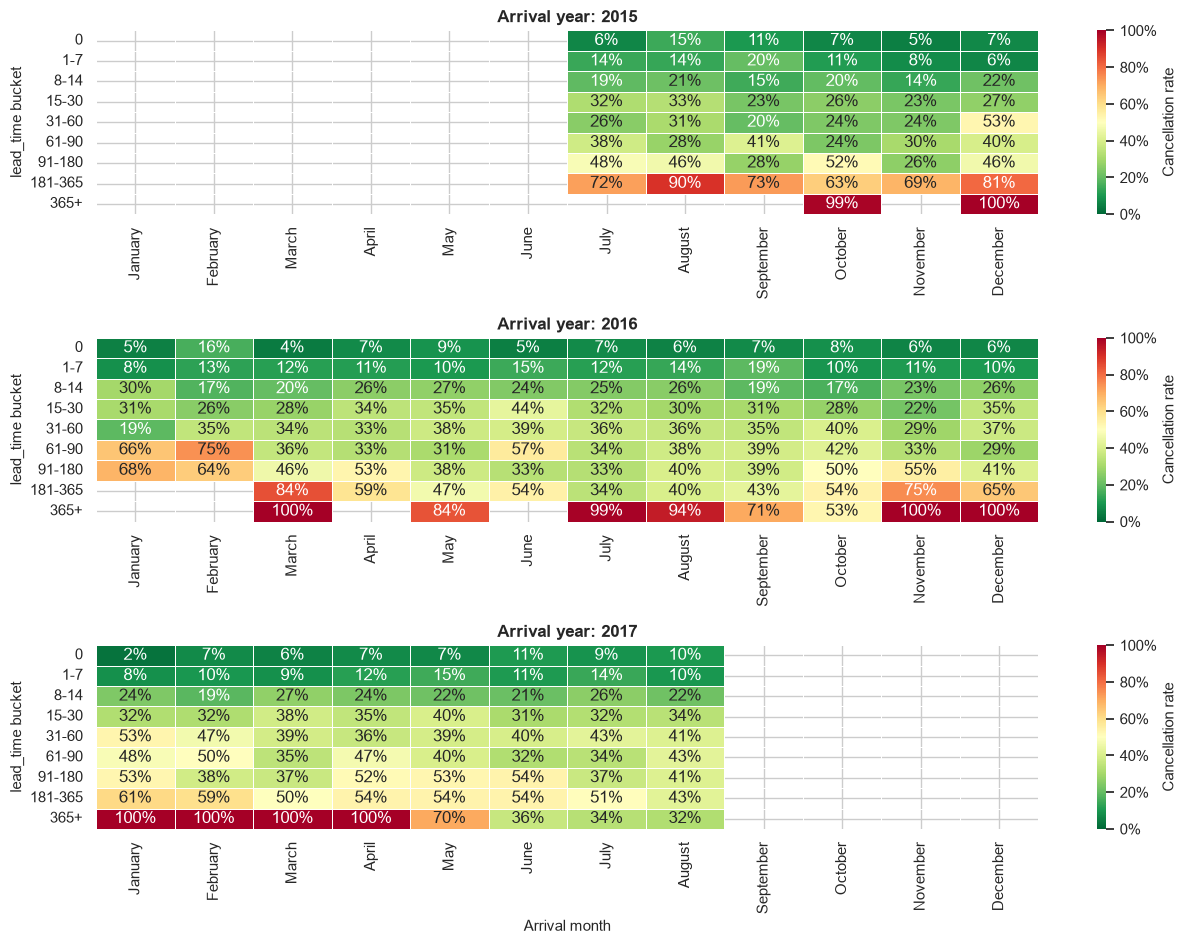

In [19]:
years = sorted(pivots.keys())

fig, axes = plt.subplots(
    nrows=len(years), ncols=1,
    figsize=(13, 3.2 * len(years)),
    sharex=False, sharey=False,
)

for ax, year in zip(axes, years):
    rate_p, n_p = pivots[year]

    sns.heatmap(
        rate_p,
        ax=ax,
        cmap='RdYlGn_r',
        vmin=0, vmax=vmax_global,
        annot=True, fmt='.0%',
        linewidths=0.5, linecolor='white',
        cbar_kws={
            'label': 'Cancellation rate',
            'format': mticker.PercentFormatter(1.0),
        },
    )

    ax.set_title(f'Arrival year: {year}', fontsize=12)
    ax.set_xlabel('Arrival month' if year == years[-1] else '')
    ax.set_ylabel('lead_time bucket')

plt.tight_layout()
plt.show()

## 2.3. Вывод

- **Доминирующий паттерн - не сезонность, а `lead_time`.** В каждом месяце каждого года доля отмен монотонно растёт с горизонтом брони. Месяц лишь немного сдвигает уровень, но не создаёт сам эффект.
- **Две "зоны" отмен:**
  - **Безопасная (0-30 дней):** обычно < 30%, часто < 15%.
  - **Рискованная (365+ дней):** практически 100% отмен во всех годах.
- **Средние горизонты (91-365 дней)** - переходная зона,
  где политика отеля реально может влиять на исход.
- **Ограничения:**
  - Цветовая шкала растянута до 100% из-за экстремальных ячеек в `365+`, мелкие различия в "зелёной" зоне визуально недооценены.
  - Сезонные различия внутри одного года видны, но делать вывод "в месяце X отменяют больше" на одном годе некорректно.

К BQ3: если доминирует `lead_time`, то стоит посмотреть профиль брони за год вперёд.

# BQ3. Кто отменяет чаще?

Разбираем "кто" через категориальные разрезы:
- 3.1 `market_segment` - рыночный сегмент.
- 3.2 `customer_type` + `distribution_channel` - тип клиента и канал брони.
- 3.3 `is_repeated_guest` - повторные и новые гости.
- 3.4 Топ-15 стран по объёму.
- 3.5 Пересечения: `hotel x market_segment`, `hotel x deposit_type`.

Везде сравниваем **доли**, а не абсолютные числа: большие группы доминируют в абсолютных числах, и это искажает восприятие.

In [20]:
seg_table = cancel_rate_table(df, 'market_segment', min_n=100)
seg_table

,market_segment,n_bookings,n_canceled,cancel_rate
0,Groups,19810,12097,0.61
1,Online TA,56476,20739,0.37
2,Offline TA/TO,24217,8309,0.34
3,Aviation,237,52,0.22
4,Corporate,5294,992,0.19
5,Direct,12606,1934,0.15
6,Complementary,743,97,0.13


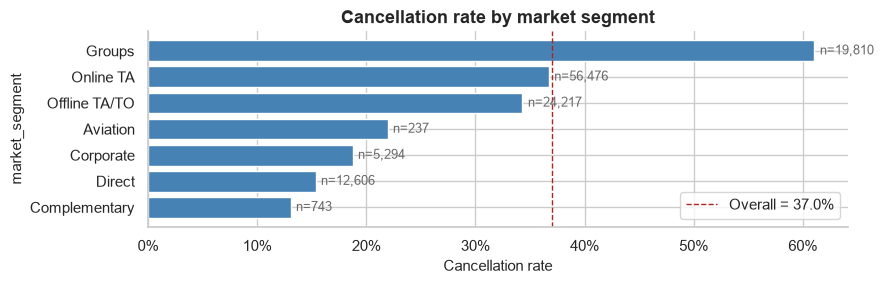

In [21]:
plot_cancel_rate(
    df, by='market_segment', min_n=100,
    title='Cancellation rate by market segment',
)
plt.tight_layout()
plt.show()

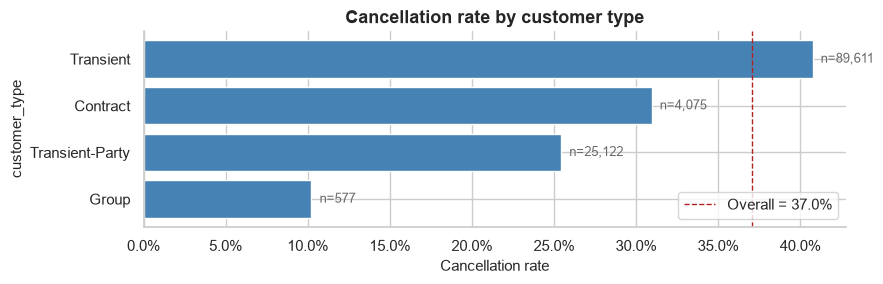

In [22]:
plot_cancel_rate(
    df, by='customer_type', min_n=100,
    title='Cancellation rate by customer type',
)
plt.tight_layout()
plt.show()

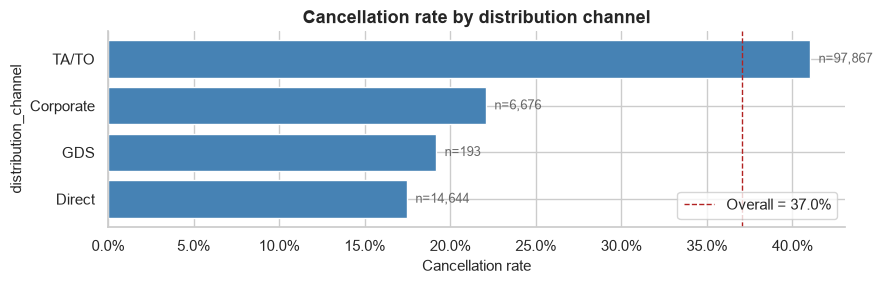

In [23]:
plot_cancel_rate(
    df, by='distribution_channel', min_n=100,
    title='Cancellation rate by distribution channel',
)
plt.tight_layout()
plt.show()

In [24]:
df['guest_type'] = (
    df['is_repeated_guest']
      .map({0: 'new', 1: 'returning'})
      .astype('category')
)

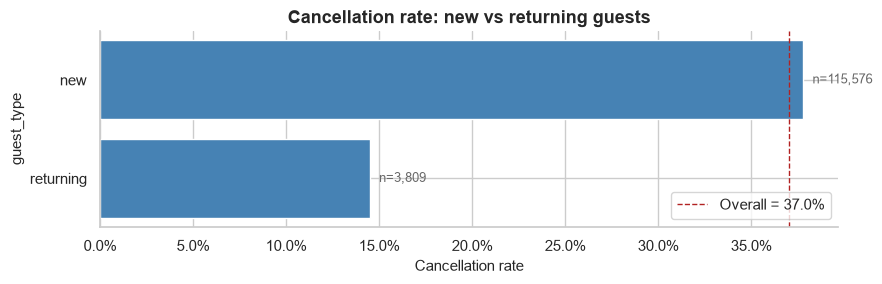

In [25]:
plot_cancel_rate(
    df, by='guest_type', min_n=0,
    title='Cancellation rate: new vs returning guests',
)
plt.tight_layout()
plt.show()

## 3.1-3.3. Вывод

- **Groups (market_segment) - 61% отмен, разрыв в 4.7 раза с Direct (15%).** Это главный сигнал сегментного разреза.
- **Примечание:** `customer_type = Group` показывает **10%** - противоположный результат. Это разные переменные с похожими именами. Groups-сегмент - это групповые брони, часто через TA/TO; Group-тип - формальная классификация брони, скорее корпоративная.
- **Direct и Corporate - "надёжны"** и по сегменту (15-19%), и по каналу (17-22%). TA/TO - источник основной массы отмен.
- **Повторные гости - 14% против 37% у новых.** В 2.6 раза реже отменяют. Также является сигналом для дальнейшего анализа.
- **Практический смысл:** Direct-брони и повторные гости - не только дешевле в привлечении, но и надёжнее по отменам. Это делает лояльность и прямые каналы экономически выгодными.

In [26]:
top_countries = (
    df['country'].value_counts()
      .head(15)
      .index
      .tolist()
)

country_table = cancel_rate_table(df, 'country', min_n=0)
country_table = (
    country_table[country_table['country'].isin(top_countries)]
    .sort_values('n_bookings', ascending=False)
    .reset_index(drop=True)
)
country_table.head(7)

,country,n_bookings,n_canceled,cancel_rate
0,PRT,48587,27517,0.57
1,GBR,12127,2453,0.20
2,FRA,10415,1934,0.19
3,ESP,8568,2177,0.25
4,DEU,7287,1218,0.17
5,ITA,3766,1333,0.35
6,IRL,3375,832,0.25


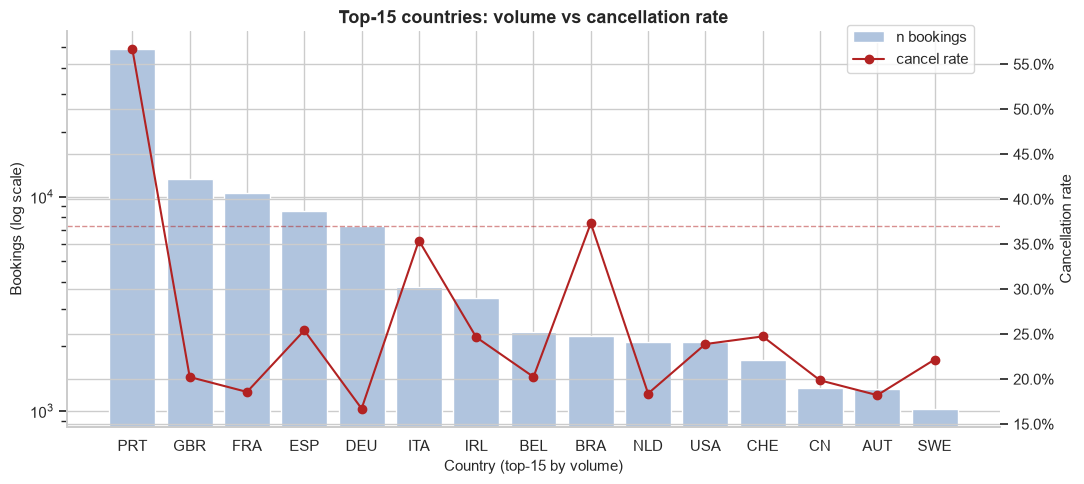

In [27]:
fig, ax1 = plt.subplots(figsize=(11, 5))

x = np.arange(len(country_table))
ax1.bar(x, country_table['n_bookings'], color='lightsteelblue', label='n bookings')
ax1.set_yscale('log')
ax1.set_ylabel('Bookings (log scale)')
ax1.set_xticks(x)
ax1.set_xticklabels(country_table['country'], rotation=0)
ax1.set_xlabel('Country (top-15 by volume)')

ax2 = ax1.twinx()
ax2.plot(x, country_table['cancel_rate'], color='firebrick',
         marker='o', linewidth=1.5, label='cancel rate')
ax2.axhline(df['is_canceled'].mean(), color='firebrick',
            linestyle='--', linewidth=1, alpha=0.5)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_ylabel('Cancellation rate')

ax1.set_title('Top-15 countries: volume vs cancellation rate')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
plt.tight_layout()
plt.show()

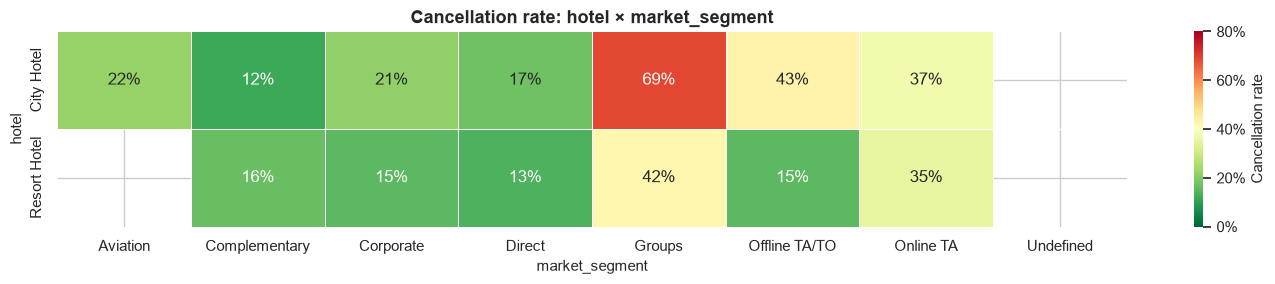

In [28]:
cancel_heatmap(df, index='hotel', columns='market_segment', min_n=100)
plt.tight_layout()
plt.show()

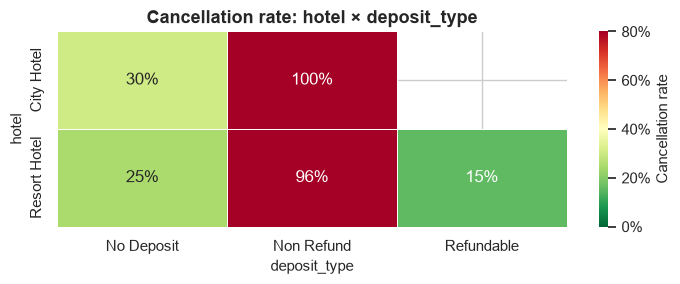

In [29]:
cancel_heatmap(df, index='hotel', columns='deposit_type', min_n=100)
plt.tight_layout()
plt.show()

## 3.6. Вывод по BQ3

**Кто отменяет чаще (по доле):**
- **Groups (market_segment)** - 61%. Direct - 15%. Разрыв в 4.7 раза.
- **Transient (customer_type)** - 40%.
- **TA/TO (distribution_channel)** - 37% (при 82% объёме).
- **Новые гости** - 37%, повторные - 14% (в 2.6 раз реже).
- **PRT** - 57% при 41% всех броней; остальные страны ровным фоном 17-25%.

**Два ключевых взаимодействия (из 3.5):**
1. **Groups x City = 69%.** Эффект "Groups" усиливается в City Hotel. В Resort Groups "всего" 42% (против 28% общий по Resort). То есть очень высокий Groups-риск - это феномен City-модели.
2. **Non Refund x City = 100% и x Resort = 96%.** Парадокс Non Refund визуально подтверждается.

**Три ключевых наблюдения высокого риска:**
- Groups + City.
- Non Refund (deposit_type).
- PRT как концентрация риска.

**Возможные рекомендации:**
- Direct-канал и возвращающиеся гости - "зелёная зона" (15-17% и 14%), но малые объёмы: развитие требует стимулов.
- Groups x City - приоритет №1 по управлению риском (69% при 19k броней).
- PRT - стоит обратить внимение на "домашний" рынок.

**Примичание:**
- `market_segment = Groups` (61% отмен) <> `customer_type = Group` (10% отмен). Это разные переменные с похожими именами. Формулировка "Groups отменяет чаще" верна только для market_segment.

# BQ4. Какие параметры влияют на отмену сильнее всего?

Для нахождении таких параметров не подойдёт функция `corr()`, так как `is_canceled` - бинарный, а большинство признаков - категориальные. Из-за чего, для ответа на данный вопрос будут использованы:
- **Cramer's V** - связь "категориальный x категориальный" (в диапазоне [0, 1]).
- **Point-biserial correlation** - связь "числовой x бинарный" (в диапазоне [-1, 1], где знак направление связи).

Оба метода - **меры ассоциации**.

`deposit_type` ожидаемо покажет очень высокую V из-за `Non Refund` (~100% отмен).

In [30]:
def cramers_v(x: pd.Series, y: pd.Series, bias_correction: bool = False) -> float:

    confusion = pd.crosstab(x, y)
    if confusion.size == 0:
        return np.nan

    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.values.sum()
    r, k = confusion.shape

    denom = n * (min(k, r) - 1)
    if denom <= 0:
        return np.nan

    v = np.sqrt(chi2 / denom)

    if bias_correction:
        phi2 = chi2 / n
        phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
        r_corr = r - (r - 1) ** 2 / (n - 1)
        k_corr = k - (k - 1) ** 2 / (n - 1)
        v = np.sqrt(phi2_corr / max(1e-12, min(k_corr - 1, r_corr - 1)))

    return v

In [31]:
# Categorical features to test. Skip LEAKAGE_COLS.
CAT_FEATURES = [
    'hotel',
    'market_segment',
    'distribution_channel',
    'customer_type',
    'deposit_type',
    'meal',
    'reserved_room_type',
    'assigned_room_type',
    'arrival_date_month',
    'is_repeated_guest',  
]

results_cat = []
for col in CAT_FEATURES:
    if col not in df.columns:
        continue
    v = cramers_v(df[col], df['is_canceled'])
    results_cat.append({'feature': col, 'cramers_v': v})

cat_v = (
    pd.DataFrame(results_cat)
      .sort_values('cramers_v', ascending=False)
      .reset_index(drop=True)
)
cat_v

,feature,cramers_v
0,deposit_type,0.48
1,market_segment,0.27
2,assigned_room_type,0.20
3,distribution_channel,0.18
4,hotel,0.14
5,customer_type,0.14
6,is_repeated_guest,0.08
7,reserved_room_type,0.07
8,arrival_date_month,0.07
9,meal,0.05


## 4.2. Point-biserial correlation (числовые x `is_canceled`)

Для числовых предикторов используем point-biserial - по сути Pearson r между числовой колонкой и бинарной

**Ограничение:** коэффициент предполагает линейную связь. Если связь монотонная, но криволинейная (как у `lead_time`) - r будет **занижен**. Смотрим на знак и порядок, а не на абсолютную величину.

In [32]:
def point_biserial_table(df, features, target='is_canceled'):
    rows = []
    for col in features:
        if col not in df.columns:
            continue
        sub = df[[col, target]].dropna()
        if sub[col].nunique() < 2:
            continue
        r, p = pointbiserialr(sub[target], sub[col])
        rows.append({
            'feature': col,
            'r': r,
            'abs_r': abs(r),
            'p_value': p,
            'n': len(sub),
        })
    return (
        pd.DataFrame(rows)
          .sort_values('abs_r', ascending=False)
          .reset_index(drop=True)
    )


NUM_FEATURES = [
    'lead_time',
    'adr',
    'total_nights',
    'total_guests',
    'booking_changes',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'days_in_waiting_list',
    'total_of_special_requests',
    'required_car_parking_spaces',
]

num_r = point_biserial_table(df, NUM_FEATURES)
num_r

,feature,r,abs_r,p_value,n
0,lead_time,0.29,0.29,0.00,119385
1,total_of_special_requests,-0.23,0.23,0.00,119385
2,required_car_parking_spaces,-0.20,0.20,0.00,119385
3,booking_changes,-0.14,0.14,0.00,119385
4,previous_cancellations,0.11,0.11,0.00,119385
5,previous_bookings_not_canceled,-0.06,0.06,0.00,119385
6,days_in_waiting_list,0.05,0.05,0.00,119385
7,adr,0.05,0.05,0.00,119385
8,total_guests,0.05,0.05,0.00,119385
9,total_nights,0.02,0.02,0.00,119385


## 4.3. Сводный рейтинг факторов

**Важно:** V и |r| - из разных методов, из-за чего прямое сопоставление **не в полной мере корректно**, но может использоваться для **относительного ранжирования** факторов внутри датасета

In [33]:
cat_part = cat_v.rename(columns={'cramers_v': 'strength'}).assign(kind='categorical')
num_part = num_r[['feature', 'abs_r']].rename(columns={'abs_r': 'strength'}).assign(kind='numeric')

combined = pd.concat([cat_part, num_part], ignore_index=True)
combined = combined.sort_values('strength', ascending=False).reset_index(drop=True)
combined[combined['strength'] > 0.1]

,feature,strength,kind
0,deposit_type,0.48,categorical
1,lead_time,0.29,numeric
2,market_segment,0.27,categorical
3,total_of_special_requests,0.23,numeric
4,assigned_room_type,0.20,categorical
5,required_car_parking_spaces,0.20,numeric
6,distribution_channel,0.18,categorical
7,booking_changes,0.14,numeric
8,hotel,0.14,categorical
9,customer_type,0.14,categorical


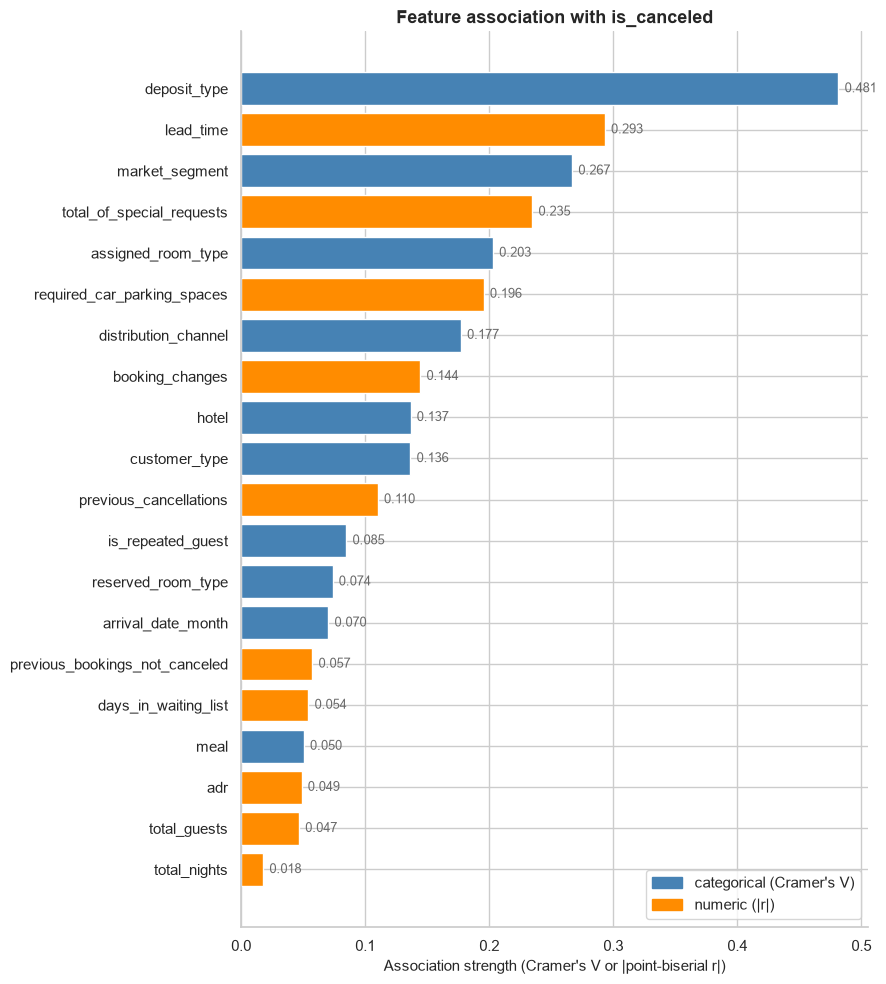

In [34]:
fig, ax = plt.subplots(figsize=(9, 0.4 * len(combined) + 2))

colors = combined['kind'].map({'categorical': 'steelblue', 'numeric': 'darkorange'})
ax.barh(combined['feature'], combined['strength'], color=colors)
ax.invert_yaxis() 
ax.set_xlabel('Association strength (Cramer\'s V or |point-biserial r|)')
ax.set_title('Feature association with is_canceled')

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color='steelblue', label='categorical (Cramer\'s V)'),
             Patch(color='darkorange', label='numeric (|r|)')],
    loc='lower right',
)

for i, (_, row) in enumerate(combined.iterrows()):
    ax.text(row['strength'] + 0.005, i, f'{row["strength"]:.3f}',
            va='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()

## 4.4. Вывод по BQ4

**Значимые факторы связанные с `is_canceled`:**

| # | Фактор | Мера | Значение | Тип |
|---|---|---|---|---|
| 1 | `deposit_type` | V | 0.48 | категориальный (артефакт) |
| 2 | `lead_time` | \|r\| | 0.29 | числовой |
| 3 | `market_segment` | V | 0.27 | категориальный |
| 4 | `total_of_special_requests` | \|r\| | 0.23 | числовой (**отрицательный**) |
| 5 | `assigned_room_type` | V | 0.20 | категориальный |
| 6 | `required_car_parking_spaces` | \|r\| | 0.20 | числовой (**отрицательный**) |
| 7 | `distribution_channel` | V | 0.18 | категориальный |

**Выводы:**

1. **`deposit_type`.** V=0.48 - формально самый значимый фактор, но связь создаётся категорией `Non Refund` (почти 100% отмен). Это артефакт данного датасета

2. **Главный фактор - `lead_time` (r=0.29).** Согласуется с BQ2.

3. **Также важный фактор - "вовлечённость гостя", который снижает риск отмены.** Три числовых значимых фактора с **отрицательным** направлением:<br>
   `total_of_special_requests` (-0.23), `required_car_parking_spaces` (-0.20), `booking_changes` (-0.14). Гость, который продумал бронь с меньшей вероятностью её отменит.

**Незначимые факторы:**
- `adr` - почти ноль (|r|=0.05). Цена сама по себе не определяет отмены.
- `total_nights` - ноль (|r|=0.02). Длина брони не связана с отменой.
- `hotel` - V=0.14, ниже ожидаемого. Но V систематически занижен для бинарных переменных, из-за чего в данном случае связь есть, но метод её занижает.

**Ограничения метода:**
- V и |r| - **ассоциация, не причинность**.
- V чувствителен к числу категорий: переменные с 10+ категориями получают завышенный V относительно бинарных.
- Point-biserial недооценивает немонотонные связи; для `lead_time` связь монотонна, но криволинейна - реальный эффект более значимый.

# 5. Проверка гипотез

**Гипотезы:**
- **H1.** `deposit_type = Non Refund` связан с экстремально высокой долей отмен
- **H2.** `lead_time` - один из сильнейших предикторов отмены
- **H3.** `market_segment = Groups` отменяет чаще остальных
- **H4.** Гости с более высокой вовлечённостью в бронь (`total_of_special_requests`, `required_car_parking_spaces`) отменяют реже

**Про p-value.** При n = 119 385 почти любая разница "статистически значима". Смотрим на величину разницы

## H1. `deposit_type = Non Refund`

**Гипотеза:** невозвратный депозит связан с экстремально высокой долей отмен (~100%, парадокс датасета).

**Метод:**
1. Базовая таблица: `deposit_type x is_canceled` (доли отмен по каждой категории)
2. Разбор `Non Refund`: кто, в каком отеле, с каким `lead_time`

In [35]:
dep_table = cancel_rate_table(df, 'deposit_type', min_n=0)
dep_table

,deposit_type,n_bookings,n_canceled,cancel_rate
0,Non Refund,14586,14493,0.99
1,No Deposit,104637,29693,0.28
2,Refundable,162,36,0.22


In [36]:
non_refund = df[df['deposit_type'] == 'Non Refund']

display(HTML(f'<b>Non Refund bookings: {len(non_refund):,}</b>'))
print()

tables_html = ""
tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>By hotel:</i></b>"
    f"{non_refund['hotel'].value_counts(dropna=False).to_frame().to_html()}"
    f"</div>"
)

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>By market_segment:</i></b>"
    f"{non_refund['market_segment'].value_counts(dropna=False).to_frame().head(5).to_html()}"
    f"</div>"
)

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>lead_time stats:</i></b>"
    f"{non_refund['lead_time'].describe().to_frame().T.to_html()}"
    f"</div>"
)

display(HTML(f"<div style='white-space:nowrap;'>{tables_html}</div>"))

,count
hotel,
City Hotel,12867
Resort Hotel,1719
,count
market_segment,
Groups,9172
Offline TA/TO,5005
Corporate,334
Online TA,56
Direct,19


In [37]:
pd.crosstab(
    df['hotel'],
    df['deposit_type'],
    values=df['is_canceled'],
    aggfunc='mean',
    margins=True,
).round(3)

deposit_type,No Deposit,Non Refund,Refundable,All
hotel,,,,
City Hotel,0.30,1.00,0.70,0.42
Resort Hotel,0.25,0.96,0.15,0.28
All,0.28,0.99,0.22,0.37


In [38]:
cont = pd.crosstab(df['deposit_type'], df['is_canceled'])
chi2, p, dof, _ = chi2_contingency(cont, correction=False)

print(f'χ² = {chi2:,.0f}')
print(f'dof  = {dof}')
print(f'p    = {p:.3e}')
print()
print('Cramer\'s V:', round(cramers_v(df['deposit_type'], df['is_canceled']), 3))

χ² = 27,675
dof  = 2
p    = 0.000e+00

Cramer's V: 0.481


In [39]:
non_refund_status = (
    non_refund['reservation_status']
      .value_counts(dropna=False)
)
non_refund_status.to_frame()

,count
reservation_status,
Canceled,14459
Check-Out,93
No-Show,34


## H1. Вывод

**Можно сказать**, что гипотеза **подтверждена**.
- `Non Refund` - 99% отмен против 28% у `No Deposit`.
- χ² = 27 675, p < 0.001, Cramer's V = 0.48.

**Но природа связи - артефакт, а не поведенческая модель:**

1. **Состав:** 63% `Groups` + 34% `Offline TA/TO` = **97%** всех `Non Refund`. Direct - 19 броней, Online TA - 56
2. **Отель:** 88% сконцентрировано в City Hotel. Но **внутри** `Non Refund` разница между отелями почти исчезает (City 100%, Resort 96%) - значит, отель не объясняет феномен.
3. **`lead_time`:** медиана 183 дня против 45 в общей выборке (в 4 раза выше). Это брони "сильно заранее".
4. **Сравнение с контролем:** в категории `No Deposit` разница City и Resort - 30% против 25%. В `Non Refund` она стирается. Значит, `deposit_type = Non Refund` - это **не поведенческая категория**, а специфический тип записи.

**Интерпретация:** связь - **ассоциация, не причинность**. Управленческого рычага в `deposit_type` нет: политика депозитов в этом датасете не отражает реальных решений гостей.

**Дополнительно:** в категории `Refundable` в City также наблюдается 70% отмен, но из-за малого количества явлений выводы сделать невозможно

**Краткие итоги:**
- 99.1% записей `Non Refund` имеют `reservation_status = Canceled`.
- То есть `deposit_type = Non Refund` - это **не характеристика брони**, а фактически синоним "отменённая бронь".
- Использовать её как предиктор в любой модели некорректно.

## H2. `lead_time` - сильный предиктор отмены

**Гипотеза:** чем больше `lead_time`, тем выше доля отмен.

**Метод:**
1. Распределение `lead_time` у отменённых и неотменённых (было сделано в 2.1)
2. **Mann-Whitney U** - формальный тест: сравнивает распределения двух групп без предположения о нормальности
3. **Effect size:** насколько сдвинуты распределения
4. Разбор: монотонность по бакетам (из heatmap 2.3)

Mann-Whitney U при n=119k даст p=0 при любом сдвиге. Смотрим на **величину** сдвига.

In [40]:
canceled_lt = df.loc[df['is_canceled'] == 1, 'lead_time']
not_canceled_lt = df.loc[df['is_canceled'] == 0, 'lead_time']

u_stat, p_val = mannwhitneyu(canceled_lt, not_canceled_lt, alternative='two-sided')

print(f'Mann-Whitney U                       = {u_stat:,.0f}')
print(f'p-value                              = {p_val:.3e}')
print()
print(f'Median lead_time (canceled)          = {canceled_lt.median():.0f} days')
print(f'Median lead_time (not canceled)      = {not_canceled_lt.median():.0f} days')
print(f'Ratio                                = {canceled_lt.median() / not_canceled_lt.median():.2f}')

Mann-Whitney U                       = 2,291,022,254
p-value                              = 0.000e+00

Median lead_time (canceled)          = 113 days
Median lead_time (not canceled)      = 45 days
Ratio                                = 2.51


In [41]:
n1, n2 = len(canceled_lt), len(not_canceled_lt)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print(f'Rank-biserial r = {r_rb:+.3f}')

Rank-biserial r = -0.379


In [42]:
no_dep = df[df['deposit_type'] == 'No Deposit']
c_lt = no_dep.loc[no_dep['is_canceled'] == 1, 'lead_time']
nc_lt = no_dep.loc[no_dep['is_canceled'] == 0, 'lead_time']
print(f'Median canceled:       {c_lt.median():.0f}')
print(f'Median not canceled:   {nc_lt.median():.0f}')
print(f'Ratio:                 {c_lt.median()/nc_lt.median():.2f}')

Median canceled:       86
Median not canceled:   45
Ratio:                 1.91


## H2. Вывод

**На всей выборке** гипотеза **подтверждена**, эффект реален.

**Без контроля:**
- Mann-Whitney U = 2.29x10^9, p = 0.
- Медиана `lead_time`: **113** / **45** дней - **2.51х**.
- Rank-biserial r = -0.38 (средне-сильный эффект).

**С контролем на `No Deposit` (артефакт H1 исключён):**
- Медиана: **86** / **45** дней - **1.91х**.
- Эффект ослаб, но сохранился.

**Интерпретация:**
- `lead_time` **не является артефактом**, в отличие от `market_segment = Groups`.
- 0.6х из наблюдаемых 2.5х приходится на пересечение с `Non Refund`, оставшиеся **1.9х** - реальный поведенческий эффект.
- Это делает `lead_time` **крупным поведенческим фактором отмены**, сохранившимся после контроля.

**Ценность наблюдения:**
- **`lead_time` управляем.** Напоминания, депозиты, гибкие тарифы на длинных горизонтах могут помочь снизить издержки.

**Ограничение:** Mann-Whitney U чувствителен к размеру выборки - при n=119k любой ненулевой сдвиг даёт p = 0. Смотрим на величину, не на p.

## H3. `market_segment = Groups`

**Гипотеза:** группы (`market_segment = Groups`) отменяют чаще остальных.

**Метод:**
1. Бинарное сравнение: `Groups` и остальные - доля, χ², V.
2. Разбор: пересечение с `hotel` (в BQ3.5 видели 69% в City, 42% в Resort).
3. Проверка "не артефакт ли это": не связан ли Groups с `deposit_type = Non Refund`.

In [43]:
df['is_groups'] = (df['market_segment'] == 'Groups').astype(int)

groups_rate = df.groupby('is_groups', observed=True)['is_canceled'].agg(['mean', 'size'])
groups_rate.index = groups_rate.index.map({0: 'not Groups', 1: 'Groups'})
groups_rate = groups_rate.rename(columns={'mean': 'cancel_rate', 'size': 'n_bookings'})
groups_rate

,cancel_rate,n_bookings
is_groups,,
not Groups,0.32,99575
Groups,0.61,19810


In [44]:
cont = pd.crosstab(df['is_groups'], df['is_canceled'])
chi2, p, dof, _ = chi2_contingency(cont, correction=False)
v = cramers_v(df['is_groups'], df['is_canceled'])
display(HTML(f'<b>All:</b>'))
print(f'χ²                = {chi2:,.0f}')
print(f'p                 = {p:.3e}')
print(f'Cramer\'s V        = {v:.3f}')
print()

cont = pd.crosstab(df[df['deposit_type'] == 'No Deposit']['is_groups'], df['is_canceled'])
chi2, p, dof, _ = chi2_contingency(cont, correction=False)
v = cramers_v(df[df['deposit_type'] == 'No Deposit']['is_groups'], df['is_canceled'])
display(HTML(f'<b>No Deposit:</b>'))
print(f'χ²                = {chi2:,.0f}')
print(f'p                 = {p:.3e}')
print(f'Cramer\'s V        = {v:.3f}')


χ²                = 5,878
p                 = 0.000e+00
Cramer's V        = 0.222



χ²                = 0
p                 = 8.575e-01
Cramer's V        = 0.001


In [45]:
non_refund_share = (
    df.groupby('is_groups', observed=True)['deposit_type']
      .apply(lambda s: (s == 'Non Refund').mean())
      .rename('share_non_refund')
)
non_refund_share.index = non_refund_share.index.map({0: 'not Groups', 1: 'Groups'})
non_refund_share.to_frame()

no_dep = df[df['deposit_type'] == 'No Deposit']

groups_clean = no_dep.groupby('is_groups', observed=True)['is_canceled'].agg(['mean', 'size'])
groups_clean.index = groups_clean.index.map({0: 'not Groups', 1: 'Groups'})
groups_clean = groups_clean.rename(columns={'mean': 'cancel_rate', 'size': 'n_bookings'})
groups_clean

tables_html = ""
tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>Non Refund:</i></b>"
    f"{non_refund_share.to_frame().to_html()}"
    f"</div>"
)

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>No Deposit:</i></b>"
    f"{groups_clean.to_html()}"
    f"</div>"
)

display(HTML(tables_html))

## H3. Вывод

**Учитывая неопределённость записей с депозитом,** и проверки гипотезы с исключением подобных записей, она **не подтверждена**.
Наблюдаемая связь есть (61% против 32%, χ²=5 878, V=0.22), но она **не проходит проверку на confounding**.

**Разбор:**

1. **Базовая картина:** Groups отменяет 61% против 32% у остальных. Разница +29 п.п. - выглядит как сильнейший сегментный фактор.

2. **Проверка на артефакт:** доля `Non Refund` в Groups = **46%**, у остальных = **5%**. То есть разница в **9** раз.

3. **Контроль: только `No Deposit` (артефакт убран):**
   - Groups: **28%**.
   - Остальные: **28%**.
   - **Разница = 0 п.п.**

4. **Интерпретация:** То, что "Groups отменяет чаще", **не соответствует действительности**. Значительная часть групповых броней идёт через канал с `deposit_type = Non Refund`, а он в этом датасете означает "уже отменено". Если убрать артефакт, Groups ведёт себя как обычная бронь.

**Что это даёт:**
- **Управленческого рычага в `market_segment = Groups` нет.** Ужесточение политики для групп не изменит поведение гостей.
- **Confounding в чистом виде:** это классический пример, когда наблюдаемая связь полностью объясняется третьей переменной.

## H4. Вовлечённость гостя снижает риск отмены

**Гипотеза:** гости, которые "вложились" в бронь (запросили special requests, попросили парковку, внесли изменения), отменяют реже.

**Контекст из секции 4:** три фактора вовлечённости попали в топ-5 по силе связи с `is_canceled`:
- `total_of_special_requests` (r = -0.23)
- `required_car_parking_spaces` (r = -0.20)
- `booking_changes` (r = -0.14)

**Метод:**
1. Бинаризация: "есть хотя бы один запрос" против "нет".
2. Crosstab + χ² + V.
3. Разбор по количеству: 0, 1, 2, 3+ запросов.

In [46]:
display(HTML(f'<b>All:</b>'))
df['has_special_request'] = (df['total_of_special_requests'] > 0).astype(int)
df['has_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)
df['has_changes'] = (df['booking_changes'] > 0).astype(int)

for col in ['has_special_request', 'has_parking', 'has_changes']:
    rate = df.groupby(col)['is_canceled'].mean()
    n = df.groupby(col)['is_canceled'].size()
    display(HTML(f'<i><b>{col}:</b></i>: no={rate[0]:.1%} (n={n[0]:,}) | yes={rate[1]:.1%} (n={n[1]:,})'))

print()

display(HTML(f'<b>No Deposit</b>'))
no_dep = df[df['deposit_type'] == 'No Deposit']

for col in ['has_special_request', 'has_parking', 'has_changes']:
    rate = no_dep.groupby(col)['is_canceled'].mean()
    n = no_dep.groupby(col)['is_canceled'].size()
    display(HTML(f'<i><b>{col}:</b></i> no={rate[0]:.1%} (n={n[0]:,}) | yes={rate[1]:.1%} (n={n[1]:,})'))

**Наблюдение**: если указаны парковочные места, то в 100% бронь не отменяется, из-за чего стоит посмотреть какие сегменты имеют не нулевые парковочные места

In [47]:
parking_cancel_count = df.loc[df['has_parking'] == 1, 'is_canceled'].sum()
display(HTML(f'<b><i>Canceled with parking</i>: {parking_cancel_count} of {(df["has_parking"]==1).sum():,}</b>'))

tables_html = ""
tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>market_segment:</i></b>"
    f"{df.loc[df['has_parking'] == 1, 'market_segment'].value_counts().to_frame().head(5).to_html()}"
    f"</div>"
)

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>distribution_channel:</i></b>"
    f"{df.loc[df['has_parking'] == 1, 'distribution_channel'].value_counts().to_frame().head(5).to_html()}"
    f"</div>"
)

display(HTML(tables_html))

,count
market_segment,
Online TA,3803
Direct,2101
Corporate,593
Offline TA/TO,552
Groups,277
,count
distribution_channel,
TA/TO,4481
Direct,2252


**Решение об исключении `has_parking`.** Ноль отмен из 7 416:<br>
Переменная, вероятно, записывается только при заезде, поэтому у отменённых броней она всегда 0. Parking (как и `reservation_status`, и `deposit_type = Non Refund`) нельзя использовать как предиктор. Используем только два "чистых" фактора вовлечённости: `total_of_special_requests` и `booking_changes`.

In [48]:
sr_table = cancel_rate_table(df, 'total_of_special_requests', min_n=0)

sr_table_no_refund = cancel_rate_table(df[df['deposit_type'] == 'No Deposit'], 'total_of_special_requests', min_n=0)

tables_html = ""
tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>Cansel by total_of_special_requests:</i></b>"
    f"{sr_table.to_html()}"
    f"</div>"
)

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b style='font-size: 16px'><i>No Deposit:</i></b>"
    f"{sr_table_no_refund.to_html()}"
    f"</div>"
)

display(HTML(tables_html))

,total_of_special_requests,n_bookings,n_canceled,cancel_rate
0,0,70315,33555,0.48
1,2,12969,2866,0.22
2,1,33224,7317,0.22
3,3,2497,446,0.18
4,4,340,36,0.11
5,5,40,2,0.05
,total_of_special_requests,n_bookings,n_canceled,cancel_rate
0,0,55609,19059,0.34
1,2,12964,2863,0.22
2,1,33188,7288,0.22


In [49]:
cont = pd.crosstab(df['has_special_request'], df['is_canceled'])
chi2, p, dof, _ = chi2_contingency(cont, correction=False)
v = cramers_v(df['has_special_request'], df['is_canceled'])
display(HTML(f'<b>All:</b>'))
print(f'χ²         = {chi2:,.0f}')
print(f'p          = {p:.3e}')
print(f"Cramer's V = {v:.3f}")
print()

cont = pd.crosstab(df[df['deposit_type'] == 'No Deposit']['has_special_request'], df['is_canceled'])
chi2, p, dof, _ = chi2_contingency(cont, correction=False)
v = cramers_v(df[df['deposit_type'] == 'No Deposit']['has_special_request'], df['is_canceled'])
display(HTML(f'<b>No Deposit</b>'))
print(f'χ²         = {chi2:,.0f}')
print(f'p          = {p:.3e}')
print(f"Cramer's V = {v:.3f}")

χ²         = 8,366
p          = 0.000e+00
Cramer's V = 0.265



χ²         = 2,030
p          = 0.000e+00
Cramer's V = 0.139


## H4. Вывод

**Гипотезу** можно считать **подтверждённой**

**Два "чистых" фактора вовлечённости:**

| Фактор | "Нет" | "Есть" | delta |
|---|---|---|---|
| `has_special_request` | 47.7% | 21.7% | -26.0 п.п. |
| `has_changes` | 40.9% | 15.7% | -25.2 п.п. |

**Только No Deposit**
| Фактор | "Нет" | "Есть" | delta |
|---|---|---|---|
| `has_special_request` | 34.3% | 21.7% | -12.6 п.п. |
| `has_changes` | 31.1% | 15.7% | -15.4 п.п. |

<br>

**χ² = 8 366, p ~ 0, Cramer's V = 0.265.** Сильнее `market_segment` на одной бинарной переменной.

**С учётом только No Deposit: χ² = 2,030, p = 0, Cramer's V = 0.139.** Всё прослеживается связь, которая имеет значение.

**`required_car_parking_spaces` исключён как артефакт:** 0 отмен из 7 416 - переменная фиксируется только при заезде.

- **Вовлечённость - единственный рычаг, на который в достаточной степени может повлиять отель.**

**Главная рекомендация:** стимулировать вовлечённость на этапе бронирования (предложение выбрать номер, запросы, возможность изменения - всё это конструируется политикой отеля).

# BQ5. Какие сегменты клиентов наиболее надёжны?

**Особенности:**
- Фильтр `min_n=200`- отсекаем случайные группы.
- Смотрим **три разреза**: `market_segment`, `customer_type`, `distribution_channel`.
- **Контроль на `No Deposit`**: сегмент не считается "надёжным", если его низкая доля отмен объясняется просто отсутствием артефакта.

In [50]:
tables_html = ""

for col in ['market_segment', 'customer_type', 'distribution_channel']:
    t = cancel_rate_table(df, col, min_n=200).sort_values('cancel_rate').reset_index(drop=True)
    tables_html += (
        f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
        f"<b style='font-size: 16px'><i>{col}:</i></b>"
        f"{t.to_html()}"
        f"</div>"
    )
display(HTML(tables_html))

,market_segment,n_bookings,n_canceled,cancel_rate
0,Complementary,743,97,0.13
1,Direct,12606,1934,0.15
2,Corporate,5294,992,0.19
3,Aviation,237,52,0.22
4,Offline TA/TO,24217,8309,0.34
5,Online TA,56476,20739,0.37
6,Groups,19810,12097,0.61
,customer_type,n_bookings,n_canceled,cancel_rate
0,Group,577,59,0.10
1,Transient-Party,25122,6389,0.25


In [51]:
no_dep = df[df['deposit_type'] == 'No Deposit']

tables_html = ""

for col in ['market_segment', 'customer_type', 'distribution_channel']:
    t = cancel_rate_table(no_dep, col, min_n=200).sort_values('cancel_rate')
    tables_html += (
        f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
        f"<b style='font-size: 16px'><i>{col} (No Deposit):</i></b>"
        f"{t.to_html()}"
        f"</div>"
    )
display(HTML(tables_html))

,market_segment,n_bookings,n_canceled,cancel_rate
6,Complementary,743,97,0.13
5,Corporate,4956,679,0.14
4,Direct,12581,1916,0.15
3,Offline TA/TO,19208,3305,0.17
2,Aviation,237,52,0.22
1,Groups,10508,2974,0.28
0,Online TA,56402,20668,0.37
,customer_type,n_bookings,n_canceled,cancel_rate
3,Group,569,59,0.10
2,Contract,3529,715,0.20


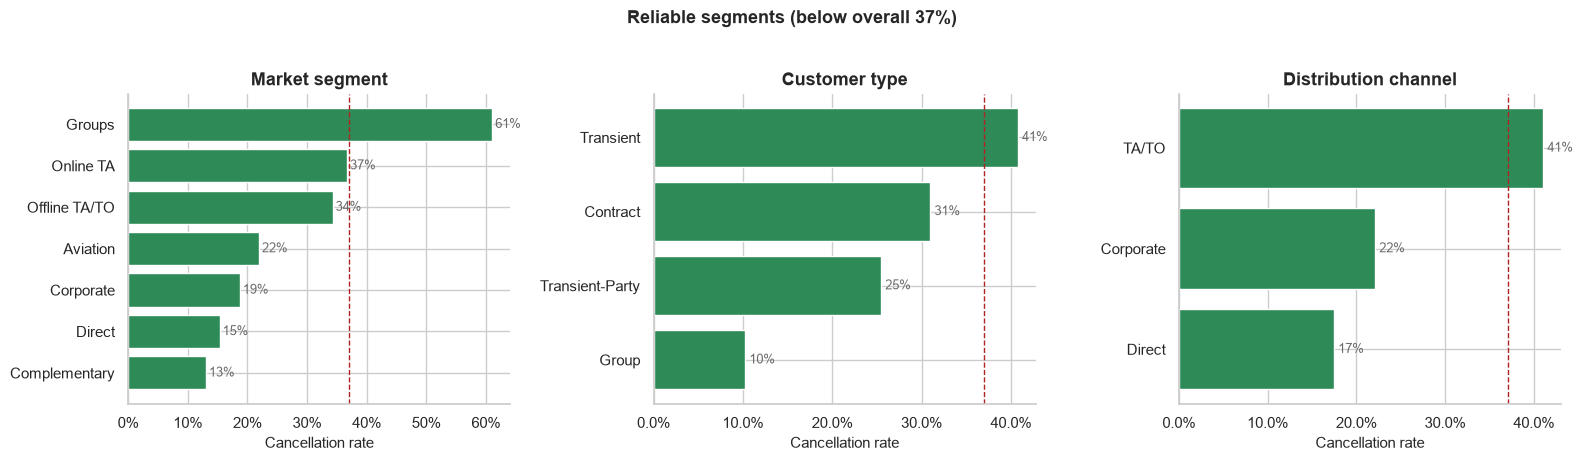

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (col, title) in zip(axes, [
    ('market_segment', 'Market segment'),
    ('customer_type', 'Customer type'),
    ('distribution_channel', 'Distribution channel'),
]):
    table = cancel_rate_table(df, col, min_n=200).sort_values('cancel_rate')
    ax.barh(table[col].astype(str), table['cancel_rate'], color='seagreen')
    ax.axvline(df['is_canceled'].mean(), color='firebrick', linestyle='--', linewidth=1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel('Cancellation rate')
    for i, (_, row) in enumerate(table.iterrows()):
        ax.text(row['cancel_rate'] + 0.005, i, f'{row["cancel_rate"]:.0%}',
                va='center', fontsize=9, color='dimgray')

plt.suptitle('Reliable segments (below overall 37%)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

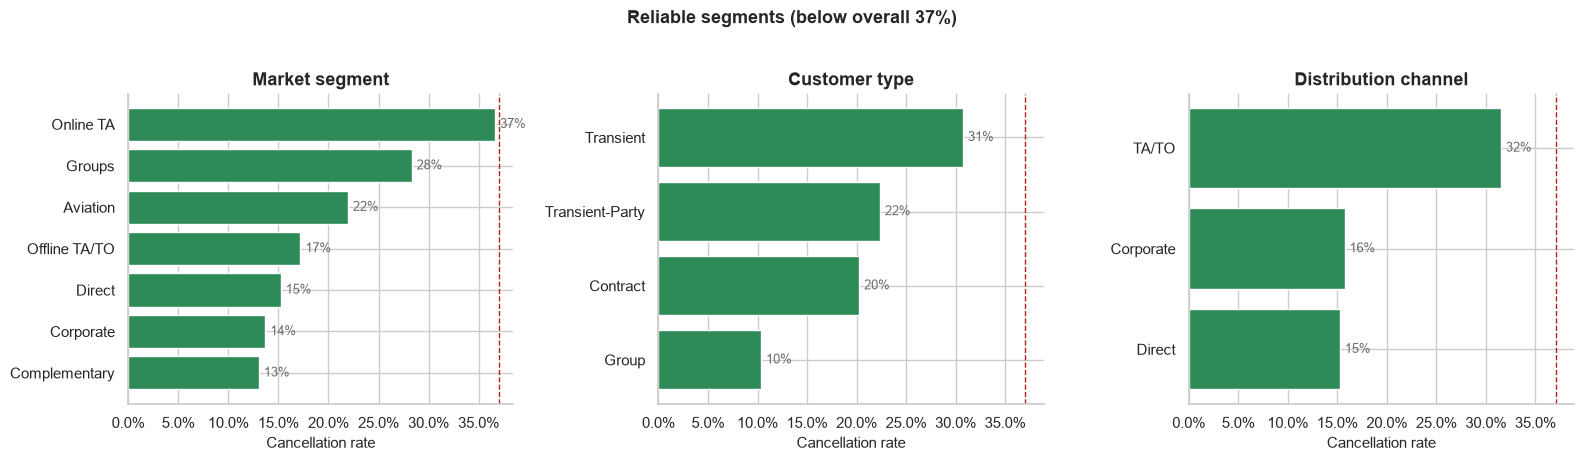

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (col, title) in zip(axes, [
    ('market_segment', 'Market segment'),
    ('customer_type', 'Customer type'),
    ('distribution_channel', 'Distribution channel'),
]):
    table = cancel_rate_table(df[df['deposit_type'] == 'No Deposit'], col, min_n=200).sort_values('cancel_rate')
    ax.barh(table[col].astype(str), table['cancel_rate'], color='seagreen')
    ax.axvline(df['is_canceled'].mean(), color='firebrick', linestyle='--', linewidth=1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel('Cancellation rate')
    for i, (_, row) in enumerate(table.iterrows()):
        ax.text(row['cancel_rate'] + 0.005, i, f'{row["cancel_rate"]:.0%}',
                va='center', fontsize=9, color='dimgray')

plt.suptitle('Reliable segments (below overall 37%)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.1 Вывод по BQ5.

**Надёжные сегменты - "зелёная зона" (после контроля на `No Deposit`):**

| Разрез | Надёжный сегмент | Доля отмен | Стабильность под контролем |
|---|---|---|---|
| market_segment | **Direct** | 15% | остаётся 15% |
| market_segment | **Corporate** | 19% | снижается до 14% |
| market_segment | Complementary | 13% | остаётся 13% |
| customer_type | Group | 10% | остаётся 10% |
| distribution_channel | **Direct** | 17% | снижается до 15% |
| distribution_channel | **Corporate** | 22% | снижается до 16% |

**Наблюдения:**

1. **Direct и Corporate - самые устойчивые сегменты.** Они надёжны во всех разрезах и во всех контролях. Прямой канал даёт более надёжных гостей **сам по себе**

2. **Offline TA/TO.** В сырых данных 34%, но под контролем 17% - почти как Direct. То есть его "риск" наполовину артефакт. В рекомендации **не попадает** как "рискованный"

3. **Online TA - риск.** 56 476 броней (самый крупный сегмент) с 37% отмен, и контроль **соcтавляет** данные неизменными. Это **проблемный** сегмент маркетинга

**Рекомендации:**
- **Развивать Direct-канал** - рычаг, который может дать надёжность и экономию на комиссии/удобство клиентам
- **Corporate-программы** - сегмент стабильно надёжен, можно также развивать
- **Online TA - фокус управления**: это большая масса с реальным высоким риском. Здесь нужно **переработать условия**: депозиты, гибкие тарифы, приоритет в напоминаниях 

# BQ6. Выручка под риском

Считаем `revenue_at_risk = sum(total_revenue)` по отменённым броням.

**Верхняя граница потерь.** Реальные потери ниже: часть номеров перепродаётся, часть отмен приходит заранее (номер успевает уйти). Мы измеряем **потенциальный ущерб**, не фактические потери.

**Два сценария:**
- **A (all):** все отмены
- **B (clean):** без `deposit_type = Non Refund`

In [54]:
def revenue_at_risk(df, label):
    canc = df[df['is_canceled'] == 1]
    total = df['total_revenue'].sum()
    risk  = canc['total_revenue'].sum()
    nights_all = df['total_nights'].sum()
    nights_canc = canc['total_nights'].sum()

    return {
        'scenario': label,
        'bookings': len(df),
        'cancelled_bookings': len(canc),
        'cancel_rate': len(canc) / len(df),
        'cancelled_nights': int(nights_canc),
        'total_nights': int(nights_all),
        'revenue_total': total,
        'revenue_at_risk': risk,
        'risk_share': risk / total,
    }


scenarios = {
    'A - all': df,
    'B - clean': df[df['deposit_type'] != 'Non Refund'],
}

summary = pd.DataFrame([revenue_at_risk(d, lbl) for lbl, d in scenarios.items()])
summary

,scenario,bookings,cancelled_bookings,cancel_rate,cancelled_nights,total_nights,revenue_total,revenue_at_risk,risk_share
0,A - all,119385,44222,0.37,154202,409227,"42,715,843.19","16,719,972.88",0.39
1,B - clean,104799,29729,0.28,114844,369656,"39,099,796.29","13,121,035.85",0.34


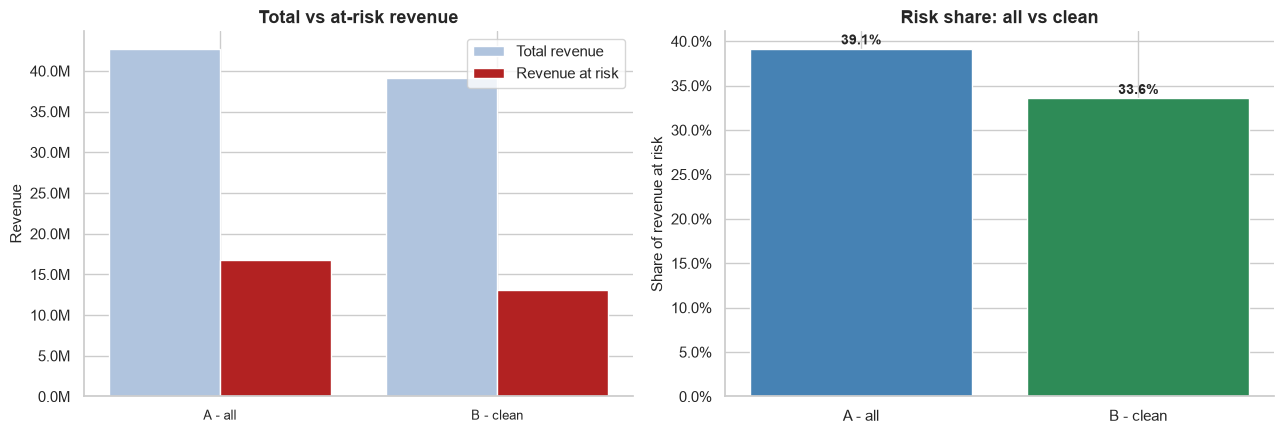

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
x = np.arange(len(summary))
ax.bar(x - 0.2, summary['revenue_total'], 0.4, label='Total revenue', color='lightsteelblue')
ax.bar(x + 0.2, summary['revenue_at_risk'], 0.4, label='Revenue at risk', color='firebrick')
ax.set_xticks(x)
ax.set_xticklabels(summary['scenario'], fontsize=9)
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.set_title('Total vs at-risk revenue')
ax.legend()

ax = axes[1]
bars = ax.bar(summary['scenario'], summary['risk_share'], color=['steelblue', 'seagreen'])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel('Share of revenue at risk')
ax.set_title('Risk share: all vs clean')
for bar, val in zip(bars, summary['risk_share']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
def risk_by(df, group_col, clean_only=False):
    sub = df[df['deposit_type'] != 'Non Refund'] if clean_only else df
    canc = sub[sub['is_canceled'] == 1]

    out = canc.groupby(group_col, observed=True).agg(
        n_cancelled=('is_canceled', 'size'),
        cancelled_nights=('total_nights', 'sum'),
        revenue_at_risk=('total_revenue', 'sum'),
    ).reset_index()

    out['risk_per_booking'] = out['revenue_at_risk'] / out['n_cancelled']
    out = out.sort_values('revenue_at_risk', ascending=False).reset_index(drop=True)
    return out


hotel_all   = risk_by(df, 'hotel', clean_only=False).assign(scenario='A - all')
hotel_clean = risk_by(df, 'hotel', clean_only=True).assign(scenario='B - clean')

hotel_risk = pd.concat([hotel_all, hotel_clean], ignore_index=True)
hotel_risk

,hotel,n_cancelled,cancelled_nights,revenue_at_risk,risk_per_booking,scenario
0,City Hotel,33101,101102,"10,879,659.78",328.68,A - all
1,Resort Hotel,11121,53100,"5,840,313.10",525.16,A - all
2,City Hotel,20258,68298,"7,718,786.94",381.02,B - clean
3,Resort Hotel,9471,46546,"5,402,248.91",570.40,B - clean


In [57]:
seg_all = risk_by(df, 'market_segment', clean_only=False).assign(scenario='A - all')
seg_clean = risk_by(df, 'market_segment', clean_only=True).assign(scenario='B - clean')

seg_risk = pd.concat([seg_all, seg_clean], ignore_index=True)
seg_risk.sort_values(by='market_segment').reset_index(drop=True)

,market_segment,n_cancelled,cancelled_nights,revenue_at_risk,risk_per_booking,scenario
0,Aviation,52,163,"16,578.00",318.81,A - all
1,Aviation,52,163,"16,578.00",318.81,B - clean
2,Complementary,97,134,269.99,2.78,A - all
3,Complementary,97,134,269.99,2.78,B - clean
4,Corporate,992,2456,"196,383.07",197.97,A - all
5,Corporate,680,1767,"132,003.07",194.12,B - clean
6,Direct,1934,7563,"993,409.82",513.66,A - all
7,Direct,1918,7527,"989,944.22",516.13,B - clean
8,Groups,12097,34397,"2,800,543.98",231.51,A - all
9,Groups,2987,9769,"645,454.91",216.09,B - clean


In [58]:
month_all = risk_by(df, 'arrival_date_month', clean_only=False).assign(scenario='A - all')
month_all = month_all.sort_values('revenue_at_risk', ascending=False)

month_all

,arrival_date_month,n_cancelled,cancelled_nights,revenue_at_risk,risk_per_booking,scenario
0,August,5239,20288,"3,027,558.37",577.89,A - all
1,July,4741,18779,"2,485,452.33",524.25,A - all
2,June,4535,15970,"1,916,096.36",422.51,A - all
3,May,4677,15018,"1,712,912.26",366.24,A - all
4,April,4524,15540,"1,610,608.66",356.01,A - all
5,September,4116,13467,"1,387,653.82",337.14,A - all
6,October,4246,13053,"1,152,732.78",271.49,A - all
7,March,3148,11677,"981,722.50",311.86,A - all
8,December,2371,8525,"712,800.41",300.63,A - all
9,February,2696,8667,"671,431.22",249.05,A - all


In [59]:
def pareto_cancelled(df, clean_only=False):
    sub = df[df['deposit_type'] != 'Non Refund'] if clean_only else df
    canc = sub[sub['is_canceled'] == 1].copy()
    canc = canc.sort_values('total_revenue', ascending=False).reset_index(drop=True)

    canc['cum_share'] = canc['total_revenue'].cumsum() / canc['total_revenue'].sum()
    canc['pct_of_cancelled'] = (canc.index + 1) / len(canc)

    return canc


pA = pareto_cancelled(df, clean_only=False)
pB = pareto_cancelled(df, clean_only=True)

def top20(canc):
    idx = int(0.2 * len(canc))
    return canc.loc[idx, 'cum_share']

print(f"A: top-20% of cancelled bookings hold {top20(pA):.1%} of revenue-at-risk")
print(f"B: top-20% of cancelled bookings hold {top20(pB):.1%} of revenue-at-risk")

A: top-20% of cancelled bookings hold 48.5% of revenue-at-risk
B: top-20% of cancelled bookings hold 48.3% of revenue-at-risk


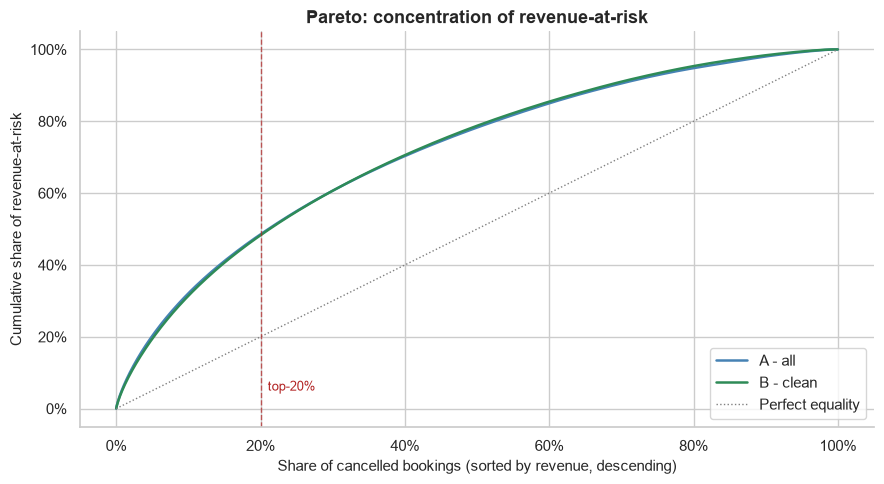

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))

for canc, label, color in [(pA, 'A - all', 'steelblue'), (pB, 'B - clean', 'seagreen')]:

    step = max(1, len(canc) // 2000)
    ax.plot(canc['pct_of_cancelled'][::step], canc['cum_share'][::step],
            label=label, color=color, linewidth=1.8)

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, label='Perfect equality')
ax.axvline(0.2, color='firebrick', linestyle='--', linewidth=1, alpha=0.7)
ax.text(0.21, 0.05, 'top-20%', color='firebrick', fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Share of cancelled bookings (sorted by revenue, descending)')
ax.set_ylabel('Cumulative share of revenue-at-risk')
ax.set_title('Pareto: concentration of revenue-at-risk')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7.2 Вывод по BQ6.

**Общий масштаб:**
- A (all): 16.7M под риском = **39.1%** всей выручки.
- B (clean, без Non Refund): 13.1M = **33.6%**.
- Разница 3.6M (5.5 п.п.) - часть, которая объясняется артефактом `deposit_type = Non Refund`. Её нельзя предъявлять как реальную потерю.

**Главный вывод: Online TA - 61% всего риска.**
- A: 10.23M из 16.72M = 61% всего риска.
- B: 10.21M - почти не меняется.
- **Online TA - реальная структурная проблема.**

**Наблюдение в выборке B в сравнении с A:**
- Groups: 2.80M -> 0.65M (**-77%**).
- Offline TA/TO: 2.49M -> 1.12M (**-55%**).
- Direct: 0.99M -> 0.99M - не изменился (**чистый** надёжный сегмент).

**Город vs Resort - разные типы риска:**
- City: 33 101 отмен по 329 за бронь -> "много, но дешевле".
- Resort: 11 121 отмен по **525** за бронь -> "меньше, но дороже" (выше ADR, длиннее stay). Per-booking риск Resort в 1.6 выше.
- Вывод: **программы для Resort гостей дают больший эффект на одного человека**.

**Сезонность риска:**
- Пик - **август** (3.0M), июль (2.5M), июнь (1.9M).
- Летний пик - следствие **максимального объёма броней + высокого ADR в сезон**.

**Парето - умеренная концентрация:**
- Топ-20% отменённых броней дают **48.5%** риска (A) и **48.3%** (B).
- Это не "80/20", что значит: **нельзя решить проблему, работая только с узкой группой дорогих отмен** - нужны широкие меры.
- Отдельно: разница между A и B по Парето минимальна - Non Refund "размазан" по всему распределению, не концентрируется в топ-дорогих.

**Оговорки:**
- **Верхняя граница потерь.** Реальные потери ниже: часть номеров перепродаётся, часть отмен приходит заранее (номер успевает уйти).
- `adr × total_nights` - возможная выручка, без налогов, допуслуг, и т.д.
- **Для бизнес-решения использовать результаты выборки B (13.1M).** Выборка A (16.7M) - только для понимания артефакта.

## *Блок перепроверки
Ранее были выявлены частые отмены при высоких lead_time. Стоит перепроверить данный вывод на выборке без `No Refund` 

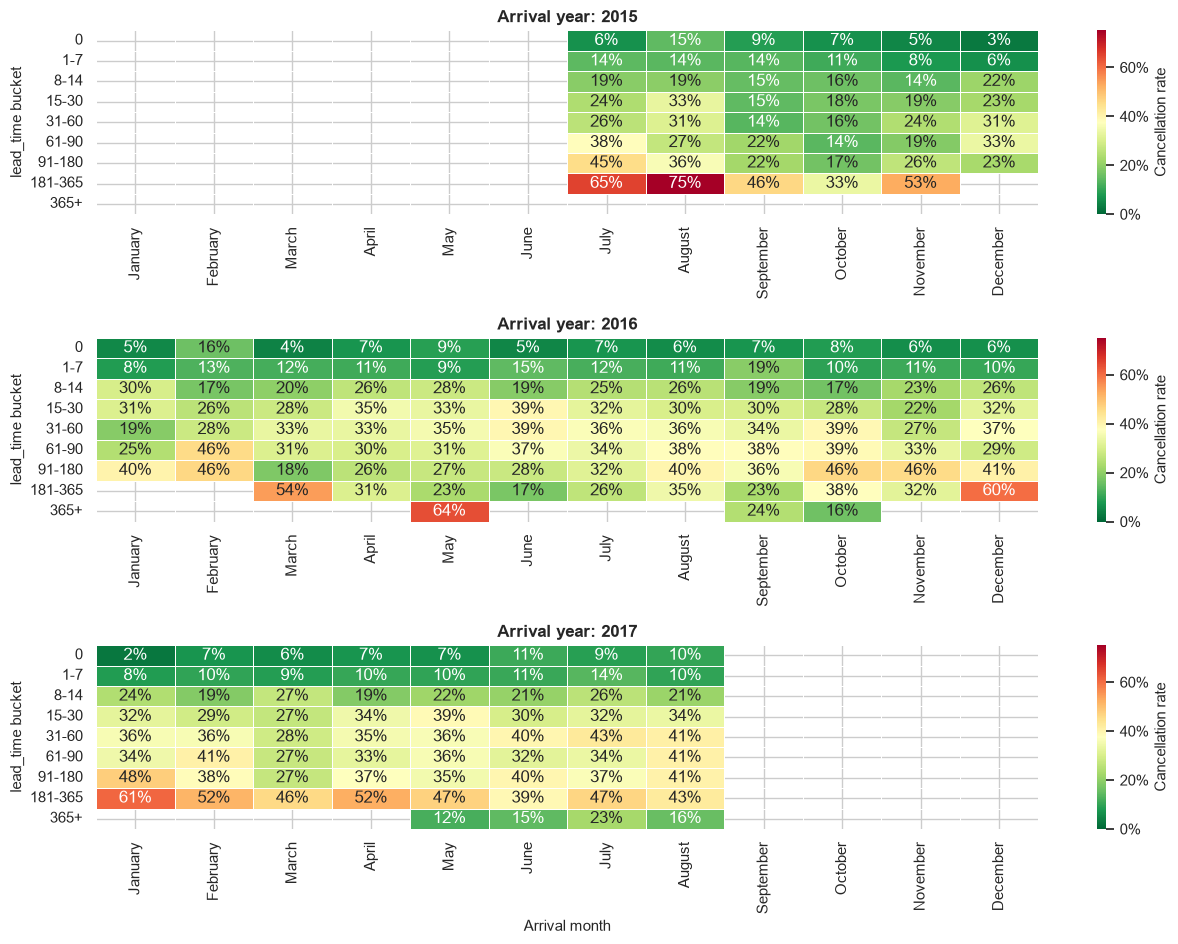

In [61]:
MONTHS_ORDER = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

MIN_N_CELL = 30
LEAD_BINS_TO_SHOW = list(df['lead_time_bin'].cat.categories)

pivots = {}
vmax_global = 0.0

for year in sorted(df['arrival_date_year'].unique()):
    sub = df[(df['arrival_date_year'] == year) & (df['deposit_type'] == 'No Deposit')]

    rate_p = sub.pivot_table(
        index='lead_time_bin',
        columns='arrival_date_month',
        values='is_canceled',
        aggfunc='mean',
        observed=False,
    )

    n_p = sub.pivot_table(
        index='lead_time_bin',
        columns='arrival_date_month',
        aggfunc='size',
        observed=False,
    )

    rate_p = rate_p.reindex(index=LEAD_BINS_TO_SHOW, columns=MONTHS_ORDER)
    n_p    = n_p.reindex(index=LEAD_BINS_TO_SHOW, columns=MONTHS_ORDER).fillna(0)

    rate_p_masked = rate_p.mask(n_p < MIN_N_CELL)

    pivots[year] = (rate_p_masked, n_p)

    if rate_p_masked.notna().any().any():
        local_max = np.nanmax(rate_p_masked.values)
        vmax_global = max(vmax_global, local_max)

years = sorted(pivots.keys())

fig, axes = plt.subplots(
    nrows=len(years), ncols=1,
    figsize=(13, 3.2 * len(years)),
    sharex=False, sharey=False,
)

for ax, year in zip(axes, years):
    rate_p, n_p = pivots[year]

    sns.heatmap(
        rate_p,
        ax=ax,
        cmap='RdYlGn_r',
        vmin=0, vmax=vmax_global,
        annot=True, fmt='.0%',
        linewidths=0.5, linecolor='white',
        cbar_kws={
            'label': 'Cancellation rate',
            'format': mticker.PercentFormatter(1.0),
        },
    )

    ax.set_title(f'Arrival year: {year}', fontsize=12)
    ax.set_xlabel('Arrival month' if year == years[-1] else '')
    ax.set_ylabel('lead_time bucket')

plt.tight_layout()
plt.show()

## *Наблюдения
На **чистой** выборке эффект от высокого lead_time стал менее заметным, но не исчез полностью. Это говорит о том, что **необходимость регулировать брони с высоким lead_time есть**

# 8. Практические рекомендации

## 8.1. Пересмотр отношений с Online TA

**Наблюдение:**
- Online TA = **61% всего `revenue_at_risk`** (10.2M из 16.7M)
- Это **"высокий риск"**, который наблюдается как на всех данных, так и на `Non Refund`
- Online TA - **самый крупный сегмент** (56 476 броней, 47% объёма)
- Средний `risk_per_booking` = 493 - выше, чем у Groups (232), но ниже, чем у Direct (514)

**Рекомендации:**
1. **Дифференцированные cancellation policies.** Ввести шкалу: отмены >30 дней - бесплатно; 7-30 - 30% штраф; <7 - 50% штраф. Это отфильтрует "бронь на всякий случай"
2. **Приоритет в напоминаниях.** Автоматический напоминания для всех Online TA-броней: за 30, 14, 7 дней до заезда
3. **Сегментация внутри Online TA.** Проверить: страны с высоким риском (PRT, ITA, BRA), конкретных агрегаторов, длинные lead_time - всё это потенциально разные подсегменты.

**Ожидаемый эффект:**
- Снижение доли отмены Online TA. Для точных показателей результатов нужны дополнительные исследования

**Как измерить:**
- `cancel_rate` для Online TA до/после изменений (месяц-к-месяцу)
- `revenue_at_risk` в разрезе Online TA
- Доля перепроданных номеров из отменённых (внутренняя метрика отеля)

## 8.2. Программа вовлечённости на этапе бронирования

**Наблюдение:**
- `has_special_request`: 48% (34% для `No Deposit`) -> **22%** отмен, -26 (-12) п.п.
- `has_changes`: 41% (31% для `No Deposit`) -> **16% (15%)** отмен, -25 (-16) п.п.
- **Пороговый эффект:** 0 -> 1 запрос даёт скачок 48% (34%) -> 22%, дальше плавное снижение. Важен сам факт наличие запросов со стороны гостя
- **Это единственный критерий, на который в полной мере может повлиять отель:** `lead_time` нельзя напрямую изменить, а форму бронирования - можно

**Действия:**
1. **Дизайн формы бронирования.** После выбора номера -   шаг с опциональными запросами: детская кроватка, поздний заезд, вид из окна, парковка, особые пожелания и т.д. Цель - конверсия 0-запросных броней в 1-запросные
2. **Стимулирование "первого шага".** В письме-подтверждении - предложение выбрать номер или дополнить бронь
3. **Возможность изменений без штрафа.** Кнопка "изменить параметры" в личном кабинете. Гость, изменивший бронь, отменяет реже
4. **Для проверки эффекта от воздействия на вовлечённость гостей** можно провести A/B-тест: часть гостей получает форму с расширенными запросами, часть - старую

**Ожидаемый эффект:**
- Перевод части брони с 0 запросов  в брони с 1 и более запросов, что **снизит долю отмен** в этих бронях

**Как измерить:**
- `cancel_rate` для группы A (с новой формой) и группы B (старая)
- `total_of_special_requests` = 0 / 1+

## 8.3. Политики для длинных lead_time

**Наблюдение:**
- Брони с `lead_time` выше ~10 дней имеют выше риск отмены, который растёт с увеличением количества дней
- Брони с  `lead_time` выше ~180 дней отменяют в 50% случаях, что также требует регулировки

**Действия:**
1. **Депозитная шкала по lead_time:** введение разных процентов и механизмов депозита в зависимости от lead_time. Стоит быть осторожным в ведении подобного инструмента и не "отпугнуть" потенциальных клиентов
2. **Напоминание для длинных броней:** за 90, 60, 30, 14 дней, за 7 дней
3. **Гибкие тарифы.** Для длинных броней - тариф "изменяемая дата без штрафа (в некотором пределе)", но с депозитом. Гость почувствует гибкость, а отель снизит риск.

**Ожидаемый эффект:**
- Снижение доли отмен с более длинными lead_time, но точные результаты зависят от окончательных решений и требуют исследований

**Как измерить:**
- `cancel_rate` по "бакетам" lead_time до/после.
- Средний депозит, удержанный по отменённым броням.

## 8.4. Развитие Direct- и Corporate-каналов

**Наблюдение:**
- **Direct:** 15% отмен, n=12 606
- **Corporate:** 14% (без `No Refund`), n=5 294
- Оба - самые надёжные сегменты в датасете
- **Дополнительная выгода:** ниже комиссия (нет TA/TO)

**Действия:**
1. **Программа лояльности для прямых броней.** Скидка 3-5% или бесплатный апгрейд при прямом бронировании. Цель: перевести часть трафика с Online TA
2. **Corporate-программы.** Для компаний - рамочные соглашения, выделенный менеджер, гибкие условия

**Ожидаемый эффект:**
- Перевод части трафика с Online TA на Direct:
  - экономия на комиссии;
  - снижение доли отмены на подобных бронях

**Как измерить:**
- Доля Direct в общем объёме (должна расти)
- Сравнение `cancel_rate` для Direct и Online TA
- Средняя комиссия на бронь (должна падать)

## 8.5. Работа с повторными гостями

**Наблюдение:**
- Повторные гости отменяют в **2.6 (2) раза реже** (14% против 37% (28%))
- Но их всего **3 809** - малая часть всех броней

**Действия:**
1. **Программа возврата.** После первого заезда - письмо с персональной скидкой 5-10% на следующую бронь
2. **Welcome-back офферы.** За 3 месяца до даты прошлого заезда - напоминание с бонусом
3. **Иные бонусы для повторных гостей.** Отдельная линия, ранний check-in, late checkout - низкая стоимость, высокая ценность для гостя.

**Ожидаемый эффект:**
- Рост доли повторных

**Как измерить:**
- Доля `is_repeated_guest` в общем объёме.
- `cancel_rate` для повторных (должен оставаться низкой)

# 9. Ограничения

## 9.1. Три столбца с неинтерпретируемыми данными

В датасете обнаружены **три переменные**, содержащие информацию о целевой переменной. Использовать их как предикторы - грубая ошибка.

1. **`reservation_status`** (`Canceled` / `Check-Out` / `No-Show`) - по сути тот же ответ, что и `is_canceled`, только в другой формулировке. Совпадение ~100%
2. **`deposit_type = Non Refund`** - 99,1% записей имеют `reservation_status = Canceled`. Это не "политика депозита", а технический маркер отменённой брони
3. **`required_car_parking_spaces`** - 0 отмен из 7 416 записей с парковкой. Переменная, вероятно, фиксируется только при заезде, поэтому у отменённых броней всегда 0

**Вывод:** эти три переменные полностью или частично исключены из анализа. Их наличие - свойство исходного датасета, а не бизнес-сигнал.

## 9.2. Временные рамки

- **Период данных:** июль 2015 - август 2017, **26 месяцев**
- **2015 и 2017 неполные**. Прямые годовые сравнения некорректны. Помесячные паттерны внутри каждого года видеть можно, но делать вывод "в 2017 стало хуже" некорректно
- **Текущие данные** могут существенно отличаться (изменение поведения, digital-каналов, политик отмены)

## 9.3. Дубликаты и качество данных

- **27% записей** помечены `is_duplicated = True` в ноутбуке 01. Они были сохранены, так как в датасете **нет надёжных идентификаторов** (booking_id и т.п.), поэтому похожие строки могут быть как техническими дублями, так и повторными бронями одного гостя, похожими бронями
- **Не удаляли**, чтобы не потерять реальные данные. Но это значит, что абсолютные числа (объёмы, выручка) могут быть завышены, если часть дублей - техническая.

## 9.4. `revenue_at_risk` - верхняя граница

Формула `sum(adr × total_nights)` по отменённым броням даёт **потенциальный ущерб**, не фактические потери.

**Не учтено:**
1. **Перепродажа номеров.** Часть отменённых номеров бронируется заново. Реальные потери - разница между выручкой с отмены и выручкой с перепродажи.
2. **Дополнительные источники выручки.** `adr` не включает различные услуги, которые предоставляет отель. Реальные потери могут быть выше или ниже в зависимости от профиля гостя.